Dataset Description

**Source:**
Pollution dataset for 5 major Indian cities (2015–2024)

**Rows:**
18265 daily observations

**Features:**
 Pollutants: PM2.5, PM10, NO2, CO, etc.,
 City, Date

**Target Variable:**
 AQI

**Goal:**
The goal of this project is to develop a time-series forecasting model that predicts daily Air Quality Index (AQI) values for major Indian cities up to the next 90 days, starting from 31-12-2024, using historical air pollution data.

Imports 

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
import math
import warnings
warnings.filterwarnings("ignore")

Data Loading 

In [94]:
df=pd.read_csv('/kaggle/input/cityday/city_day.csv')
df

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18260,Delhi,2024-12-31,371.2,61.7,14.6,130.7,159.1,45.9,7.02,76.4,40.0,7.99,5.71,0.36,61.5,Poor
18261,Mumbai,2024-12-31,180.2,259.3,181.9,50.7,135.7,22.4,8.85,12.2,147.3,13.93,7.15,2.08,312.7,Satisfactory
18262,Chennai,2024-12-31,188.6,434.4,68.8,126.1,142.7,47.0,8.30,50.2,128.6,6.98,6.71,2.10,366.1,Good
18263,Kolkata,2024-12-31,343.0,458.6,106.7,108.3,137.8,22.6,2.11,71.4,175.8,4.12,11.68,0.88,397.5,Good


In [95]:
df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [97]:
print("\nData Info:")
df.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  object 
 1   Datetime    18265 non-null  object 
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  Benzene     18265 non-null  float64
 12  Toluene     18265 non-null  float64
 13  Xylene      18265 non-null  float64
 14  AQI         18265 non-null  float64
 15  AQI_Bucket  18265 non-null  object 
dtypes: float64(13), object(3)
memory usage: 2.2+ MB


In [98]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000
mean,250.597695,299.442491,100.481035,75.415916,125.964079,25.065042,5.002451,49.835839,100.406740,10.070033,15.063365,4.996341,251.111382
std,144.460292,173.479906,57.774795,43.460066,72.403893,14.452019,2.889439,28.988739,57.591436,5.785282,8.619433,2.899152,144.502626
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,125.700000,150.100000,50.600000,37.700000,63.100000,12.600000,2.490000,24.400000,50.600000,5.080000,7.640000,2.510000,125.400000
50%,251.000000,300.300000,100.200000,76.000000,126.200000,25.300000,5.000000,49.900000,100.700000,10.080000,15.130000,4.960000,251.200000
75%,376.200000,450.000000,151.000000,113.200000,188.900000,37.600000,7.510000,75.100000,150.400000,15.110000,22.500000,7.530000,376.400000
max,499.900000,600.000000,200.000000,150.000000,250.000000,50.000000,10.000000,100.000000,200.000000,20.000000,30.000000,10.000000,500.000000


In [99]:
#globally defining
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']

Data Cleaning and preprocessing

In [100]:
df['Date'] = pd.to_datetime(df['Datetime'], errors='coerce')
df. drop('Datetime', axis=1, inplace=True)
df = df.dropna(subset=['Date', 'AQI'])
df = df. sort_values(['City', 'Date'])  
df. set_index('Date', inplace=True)

EDA

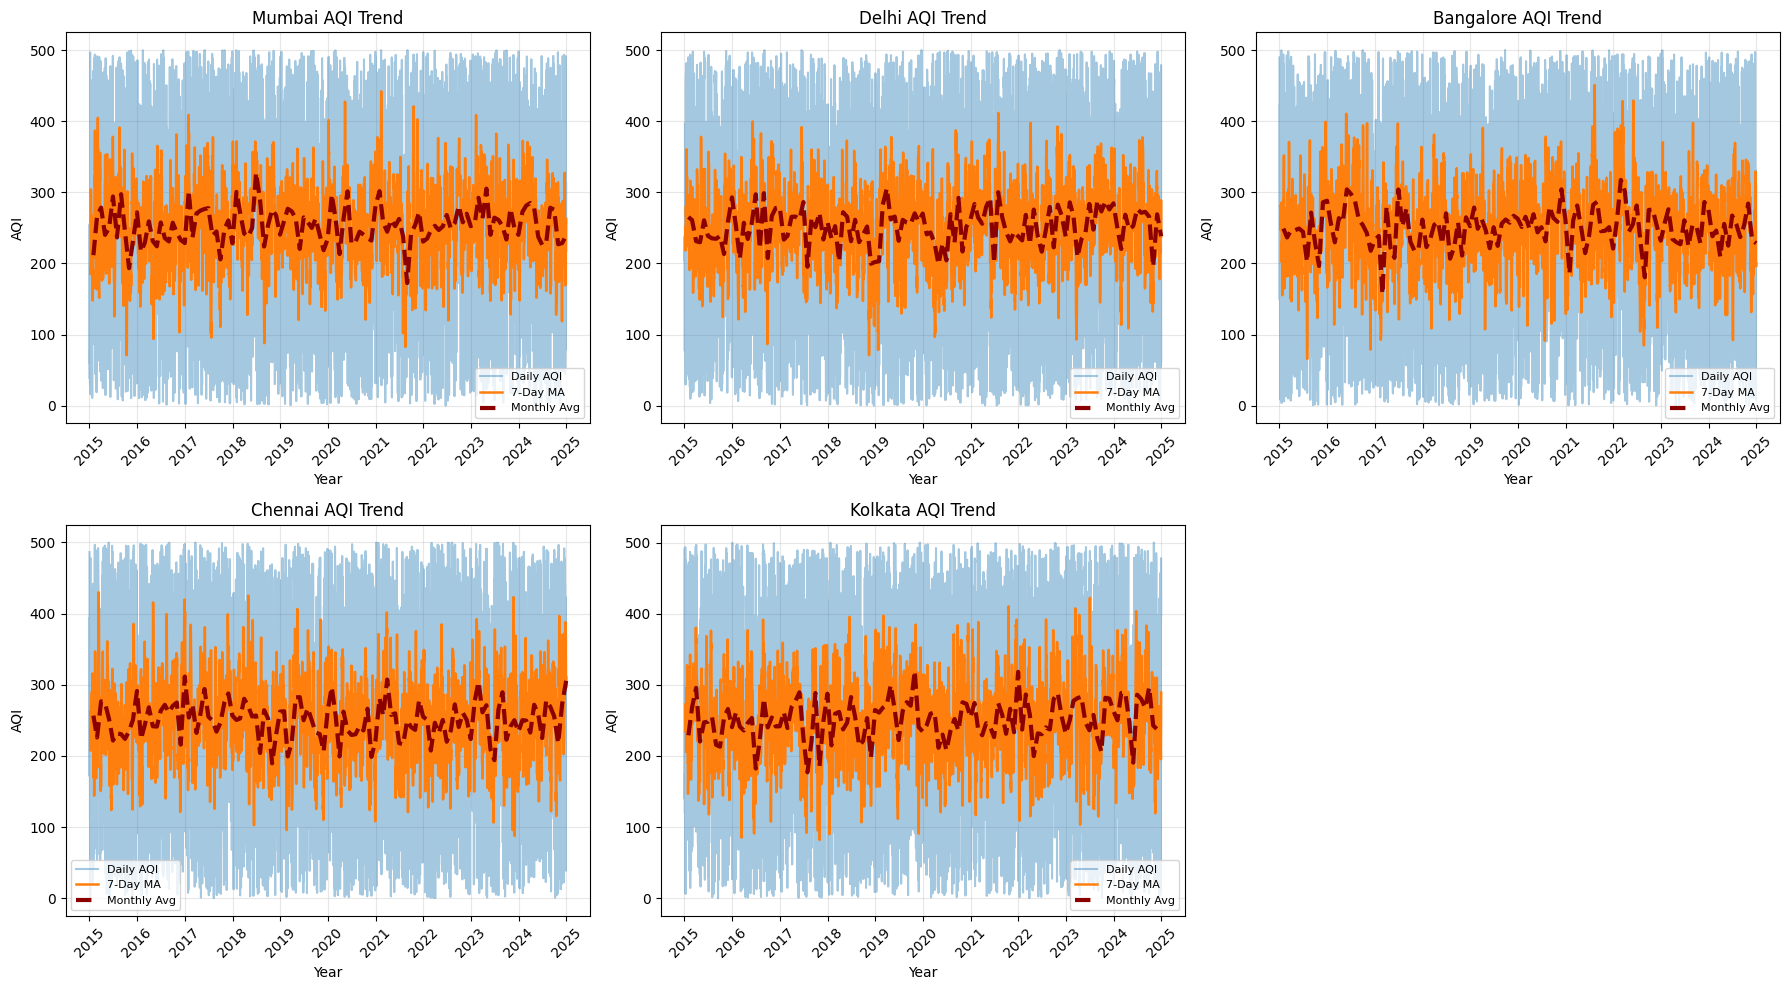

In [101]:
cities = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Kolkata']
rows, cols = 2, 3
plt.figure(figsize=(18, 10))

for i, city in enumerate(cities, 1):
    city_df = df[df['City'] == city].copy()
    city_df['AQI_7day_MA'] = city_df['AQI'].rolling(window=7).mean()
    monthly_aqi = city_df['AQI'].resample('M').mean()

    plt.subplot(rows, cols, i)

    plt.plot(city_df.index, city_df['AQI'], alpha=0.4, label='Daily AQI')
    plt.plot(city_df.index, city_df['AQI_7day_MA'], label='7-Day MA', linewidth=1.8)
    plt.plot(monthly_aqi.index, monthly_aqi.values, linestyle='--', linewidth=3, color='darkred', label='Monthly Avg')

    plt.title(f'{city} AQI Trend')
    plt.xlabel('Year')
    plt.ylabel('AQI')
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


STATIONARITY TESTS
City         | ADF p-value  | KPSS p-value | Stationary? 
Mumbai       | 0.0000       | 0.1000       | Yes
Delhi        | 0.0000       | 0.1000       | Yes
Bangalore    | 0.0000       | 0.1000       | Yes
Chennai      | 0.0000       | 0.1000       | Yes
Kolkata      | 0.0000       | 0.1000       | Yes


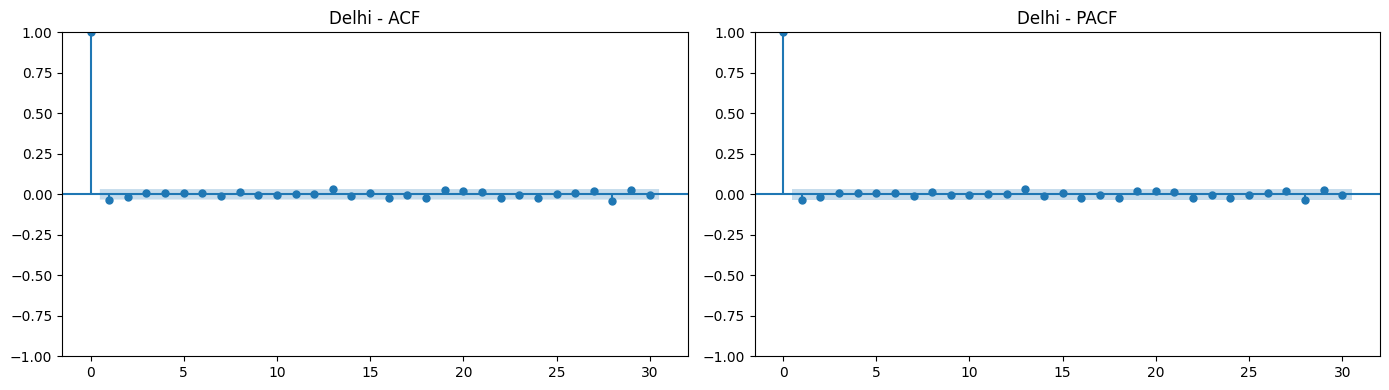


📝 Conclusion:  Data shows WEAK autocorrelation - minimal lag features needed


In [102]:
from statsmodels.tsa.stattools import adfuller, kpss
warnings.filterwarnings('ignore')
print("STATIONARITY TESTS")
print(f"{'City':<12} | {'ADF p-value':<12} | {'KPSS p-value':<12} | {'Stationary? '}")

for city in cities:
    series = df[df['City'] == city]['AQI']. dropna()
    if len(series) < 50:
        continue
    
    adf_p = adfuller(series)[1]
    kpss_p = kpss(series, regression='c', nlags='auto')[1]
    
    # Interpretation
    is_stationary = "Yes" if (adf_p < 0.05 and kpss_p >= 0.05) else "Partial/No"
    
    print(f"{city:<12} | {adf_p: <12.4f} | {kpss_p:<12.4f} | {is_stationary}")

# ACF/PACF for one city
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sample_city = 'Delhi'
city_series = df[df['City'] == sample_city]['AQI']. dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(city_series, lags=30, ax=axes[0])
axes[0].set_title(f'{sample_city} - ACF')
plot_pacf(city_series, lags=30, ax=axes[1])
axes[1].set_title(f'{sample_city} - PACF')
plt.tight_layout()
plt.show()

print("\n📝 Conclusion:  Data shows WEAK autocorrelation - minimal lag features needed")

Feature Engineering

In [103]:
def get_season(city, month):
    """Get season based on city and month."""
    # Mumbai, Bangalore, Kolkata
    if city in ['Mumbai', 'Bangalore', 'Kolkata']:
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]: 
            return 'Summer'
        elif month in [6, 7, 8, 9]:
            return 'Monsoon'
        else:
            return 'Post-Monsoon'
    
    # Delhi
    elif city == 'Delhi': 
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5, 6]:
            return 'Summer'
        elif month in [7, 8, 9]: 
            return 'Monsoon'
        else:
            return 'Post-Monsoon'
    
    # Chennai
    elif city == 'Chennai':
        if month in [1, 2]: 
            return 'Winter'
        elif month in [3, 4, 5, 6]:
            return 'Summer'
        elif month in [7, 8, 9]: 
            return 'SW-Monsoon'
        else: 
            return 'NE-Monsoon'
    
    # Default
    else:
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]: 
            return 'Summer'
        elif month in [6, 7, 8, 9]: 
            return 'Monsoon'
        else:
            return 'Post-Monsoon'

# Temporal features
df['Month'] = df. index.month
df['Year'] = df.index.year
df['DayOfWeek'] = df.index.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Cyclical encoding for month
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Season
df['Season'] = df.apply(lambda x: get_season(x['City'], x['Month']), axis=1)

# MINIMAL lag features (based on weak autocorrelation finding)
df['AQI_lag1'] = df. groupby('City')['AQI'].shift(1)
df['AQI_roll_mean_7'] = df.groupby('City')['AQI'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)

# Pollutant ratio (PM2.5 and PM10 are key predictors)
if 'PM2.5' in df.columns and 'PM10' in df.columns:
    df['PM_ratio'] = df['PM2.5'] / (df['PM10'] + 1e-8)

# Drop rows with NaN in key features
df = df.dropna(subset=['AQI', 'AQI_lag1'])

print(f"Dataset shape after feature engineering: {df.shape}")

Dataset shape after feature engineering: (18260, 25)


Train Test Split

In [104]:
# TARGET SELECTION
y = df['AQI']
X = df.drop(columns=['AQI', 'AQI_Bucket'], errors='ignore')

In [105]:
# Use last 6 months as test set
split_date = df.index.max() - pd.DateOffset(months=6)

# Time-based split
X_train = X[X.index < split_date]
X_test  = X[X.index >= split_date]

y_train = y[y.index < split_date]
y_test  = y[y.index >= split_date]

# Sanity check
print(f"Train: {X_train.index.min()} → {X_train.index.max()}")
print(f"Test : {X_test.index.min()} → {X_test.index.max()}")

# Save feature columns for later
feature_cols = list(X. columns)
print(f"\nNumber of features: {len(feature_cols)}")

Train: 2015-01-02 00:00:00 → 2024-06-29 00:00:00
Test : 2024-06-30 00:00:00 → 2024-12-31 00:00:00

Number of features: 23


Preprocessing Pipelines

In [106]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [107]:
# Categorical features (only these two)
categorical_features = ['City', 'Season']

# All other columns except target + categorical → numeric
numeric_features = [
    col for col in df.columns
    if col not in categorical_features
    and col not in ['AQI', 'AQI_Bucket']  # remove targets
]

In [108]:
# Numerical pipeline → Only impute missing values
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical pipeline → impute + OneHotEncode
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)


Model Training

In [109]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
RANDOM_STATE=41

In [110]:
# =============================================================================
# 8. MODEL TRAINING
# =============================================================================
print("Training models.. .\n")

# Baseline: Persistence (yesterday's AQI)
y_pred_persist = X_test['AQI_lag1'].values

# Random Forest
rf_model = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("✅ Random Forest trained")

# XGBoost
xgb_model = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, 
                                random_state=RANDOM_STATE, n_jobs=-1))
])
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model. predict(X_test)
print("✅ XGBoost trained")

# LightGBM (optional - uncomment if installed)
try:
    from lightgbm import LGBMRegressor
    lgbm_model = Pipeline([
        ('preprocess', preprocessor),
        ('regressor', LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                     random_state=RANDOM_STATE, verbose=-1, n_jobs=-1))
    ])
    lgbm_model.fit(X_train, y_train)
    y_pred_lgbm = lgbm_model.predict(X_test)
    print("✅ LightGBM trained")
    HAS_LGBM = True
except ImportError:
    print("⚠️ LightGBM not installed - skipping")
    HAS_LGBM = False

# Ensemble (simple average)
if HAS_LGBM: 
    y_pred_ensemble = (y_pred_rf + y_pred_xgb + y_pred_lgbm) / 3
else:
    y_pred_ensemble = (y_pred_rf + y_pred_xgb) / 2
print("✅ Ensemble created")

Training models.. .

✅ Random Forest trained
✅ XGBoost trained
✅ LightGBM trained
✅ Ensemble created


Hyperparameter tuning

In [111]:
from sklearn.model_selection import TimeSeriesSplit
!pip install optuna
import optuna
from optuna.samplers import TPESampler

In [153]:
# =============================================================================
# BAYESIAN OPTIMIZATION (Optuna)
# ============================================================================
print("\n4️⃣ Bayesian Optimization with Optuna...")
    
def objective(trial):
        """Optuna objective function for XGBoost."""
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial. suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample':  trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 0.5),
            'reg_alpha': trial. suggest_float('reg_alpha', 1e-8, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        }
        
        # Create pipeline
        model = Pipeline([
            ('preprocess', preprocessor),
            ('regressor', XGBRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1))
        ])
        
        # Time series cross-validation
        scores = []
        for train_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train. iloc[train_idx], X_train. iloc[val_idx]
            y_tr, y_val = y_train. iloc[train_idx], y_train. iloc[val_idx]
            
            model.fit(X_tr, y_tr)
            y_pred = model. predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            scores.append(rmse)
        
        return np.mean(scores)
    
    # Create study
sampler = TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='minimize', sampler=sampler)
    
    # Optimize (suppress output)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=50, show_progress_bar=True)
    
print(f"\n✅ Optuna Optimization Complete")
print(f"Best Parameters:{study.best_params}")
print(f"Best CV RMSE:{study.best_value:.2f}")
    
    # Train final model with best params
best_xgb_optuna = Pipeline([
        ('preprocess', preprocessor),
        ('regressor', XGBRegressor(**study.best_params, random_state=RANDOM_STATE, n_jobs=-1))
    ])
best_xgb_optuna.fit(X_train, y_train)
y_pred_optuna = best_xgb_optuna. predict(X_test)
optuna_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_optuna))
print(f"Test RMSE: {optuna_test_rmse:.2f}")


4️⃣ Bayesian Optimization with Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optuna Optimization Complete
Best Parameters:{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.011646418655441181, 'subsample': 0.9649844984829523, 'colsample_bytree': 0.6647417707266884, 'min_child_weight': 2, 'gamma': 0.2792648175414027, 'reg_alpha': 3.223043778895876e-07, 'reg_lambda': 0.003500961363482862}
Best CV RMSE:144.60
Test RMSE: 145.39


In [113]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


MODEL COMPARISON (Multiple Metrics)
        Model    MAE   RMSE   MAPE    R2  Direction_Acc
  Persistence 170.38 207.50 399.50 -1.04          32.47
 RandomForest 127.34 146.02 306.54 -0.01          50.97
      XGBoost 127.95 147.68 310.52 -0.04          52.38
     LightGBM 128.76 147.93 314.16 -0.04          51.84
     Ensemble 127.73 146.67 310.29 -0.02          51.30
Tuned_XGBoost 126.98 145.29 308.66 -0.00          52.92

🏆 Best Model: Tuned_XGBoost


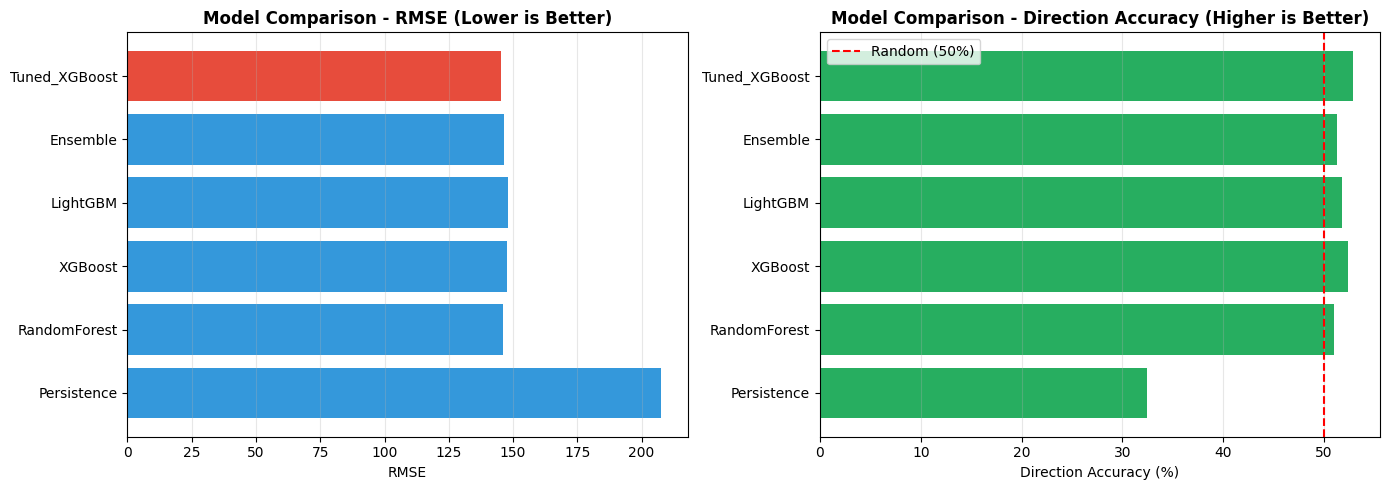

In [114]:
# =============================================================================
# 10. MODEL EVALUATION
# =============================================================================
def evaluate_model(y_true, y_pred, model_name):
    """Comprehensive evaluation metrics."""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true, y_pred = y_true[mask], y_pred[mask]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # MAPE
    non_zero = y_true != 0
    mape = np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100
    
    # Direction Accuracy
    if len(y_true) > 1:
        actual_dir = np.diff(y_true) > 0
        pred_dir = np.diff(y_pred) > 0
        dir_acc = np.mean(actual_dir == pred_dir) * 100
    else: 
        dir_acc = np.nan
    
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 
            'R2': r2, 'Direction_Acc': dir_acc}

# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred_persist, 'Persistence'))
results.append(evaluate_model(y_test, y_pred_rf, 'RandomForest'))
results.append(evaluate_model(y_test, y_pred_xgb, 'XGBoost'))
if HAS_LGBM: 
    results.append(evaluate_model(y_test, y_pred_lgbm, 'LightGBM'))
results.append(evaluate_model(y_test, y_pred_ensemble, 'Ensemble'))
results.append(evaluate_model(y_test, y_pred_best, 'Tuned_XGBoost'))

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print("MODEL COMPARISON (Multiple Metrics)")
print("="*80)
print(results_df.round(2).to_string(index=False))

# Best model by RMSE
best_model_name = results_df.loc[results_df['RMSE'].idxmin(), 'Model']
print(f"\n🏆 Best Model: {best_model_name}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
ax1 = axes[0]
colors = ['#e74c3c' if m == best_model_name else '#3498db' for m in results_df['Model']]
bars = ax1.barh(results_df['Model'], results_df['RMSE'], color=colors)
ax1.set_xlabel('RMSE')
ax1.set_title('Model Comparison - RMSE (Lower is Better)', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Direction Accuracy comparison
ax2 = axes[1]
ax2.barh(results_df['Model'], results_df['Direction_Acc'], color='#27ae60')
ax2.set_xlabel('Direction Accuracy (%)')
ax2.set_title('Model Comparison - Direction Accuracy (Higher is Better)', fontweight='bold')
ax2.axvline(x=50, color='red', linestyle='--', label='Random (50%)')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

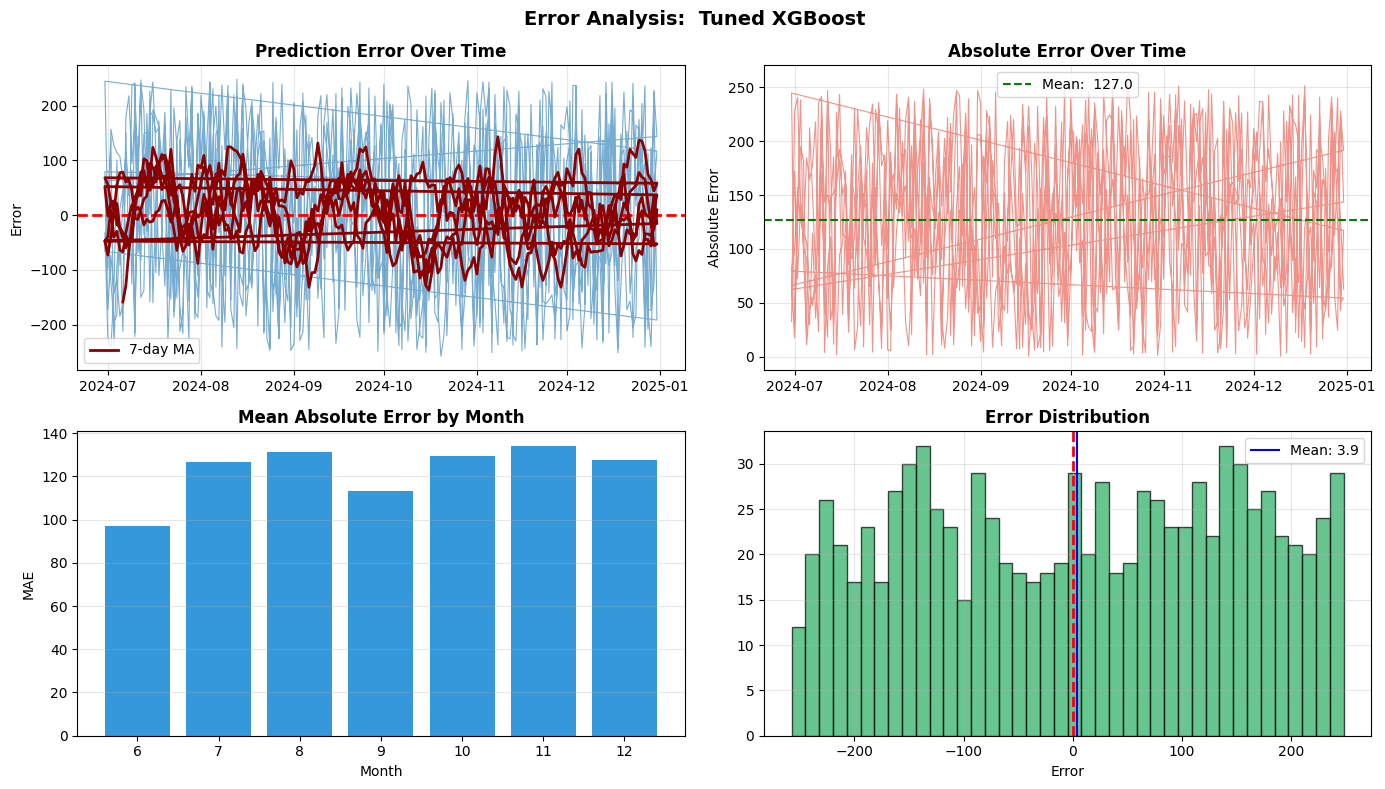

In [143]:
# =============================================================================
# ESSENTIAL ADDITION 1: ERROR OVER TIME PLOT
# =============================================================================
# PLACE AFTER: Model Evaluation (Section 10)

def plot_error_over_time_simple(y_true, y_pred, dates, model_name="Model"):
    """Simple error over time visualization."""
    errors = np.array(y_true) - np.array(y_pred)
    abs_errors = np. abs(errors)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # 1. Error over time
    ax1 = axes[0, 0]
    ax1.plot(dates, errors, alpha=0.6, linewidth=0.8)
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
    rolling_error = pd.Series(errors).rolling(window=7).mean()
    ax1.plot(dates, rolling_error, color='darkred', linewidth=2, label='7-day MA')
    ax1.set_title('Prediction Error Over Time', fontweight='bold')
    ax1.set_ylabel('Error')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Absolute error over time
    ax2 = axes[0, 1]
    ax2.plot(dates, abs_errors, alpha=0.6, color='#e74c3c', linewidth=0.8)
    ax2.axhline(y=np.mean(abs_errors), color='green', linestyle='--', 
                label=f'Mean:  {np.mean(abs_errors):.1f}')
    ax2.set_title('Absolute Error Over Time', fontweight='bold')
    ax2.set_ylabel('Absolute Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Error by Month
    ax3 = axes[1, 0]
    error_df = pd.DataFrame({'Date': dates, 'AbsError': abs_errors})
    error_df['Month'] = pd.to_datetime(error_df['Date']).dt.month
    monthly_error = error_df. groupby('Month')['AbsError']. mean()
    ax3.bar(monthly_error.index, monthly_error.values, color='#3498db')
    ax3.set_title('Mean Absolute Error by Month', fontweight='bold')
    ax3.set_xlabel('Month')
    ax3.set_ylabel('MAE')
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Error distribution
    ax4 = axes[1, 1]
    ax4.hist(errors, bins=40, alpha=0.7, color='#27ae60', edgecolor='black')
    ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax4.axvline(x=errors.mean(), color='blue', linestyle='-', 
                label=f'Mean: {errors.mean():.1f}')
    ax4.set_title('Error Distribution', fontweight='bold')
    ax4.set_xlabel('Error')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'Error Analysis:  {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Plot
plot_error_over_time_simple(y_test. values, y_pred_best, y_test.index, "Tuned XGBoost")

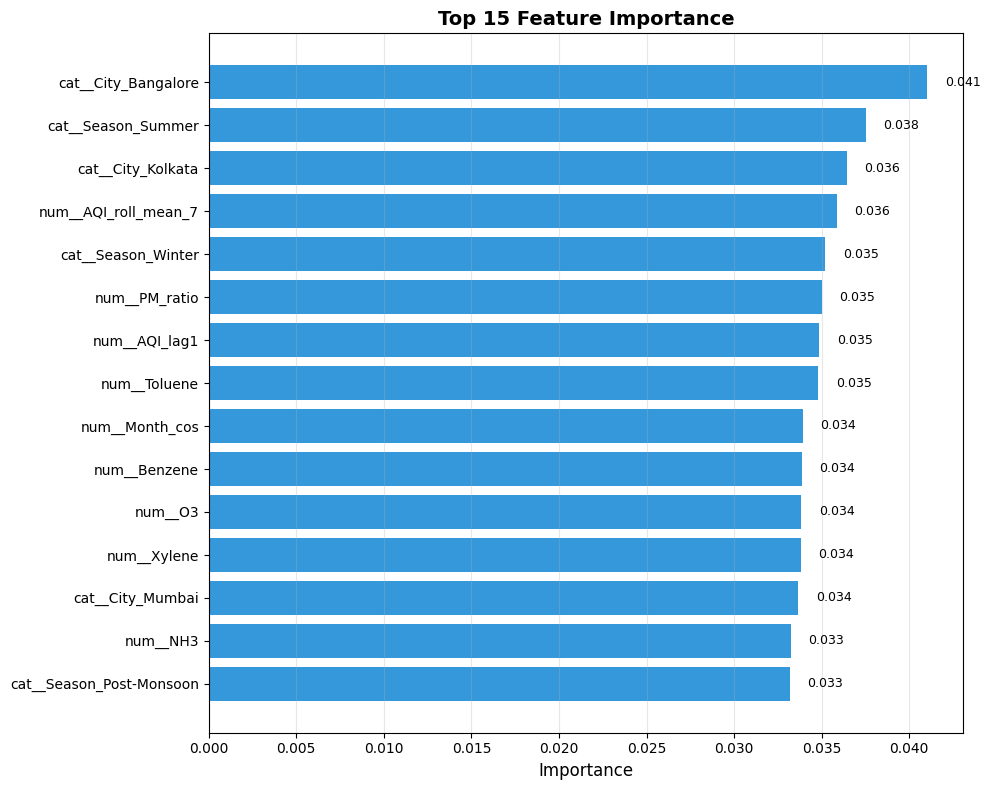


📊 Top 10 Most Important Features:
             Feature  Importance
 cat__City_Bangalore    0.041028
  cat__Season_Summer    0.037528
   cat__City_Kolkata    0.036449
num__AQI_roll_mean_7    0.035851
  cat__Season_Winter    0.035200
       num__PM_ratio    0.034997
       num__AQI_lag1    0.034867
        num__Toluene    0.034805
      num__Month_cos    0.033928
        num__Benzene    0.033865


In [115]:
# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================

def plot_feature_importance(pipeline, top_n=15):
    """Plot feature importance from trained pipeline."""
    
    # Get the regressor from pipeline
    regressor = pipeline. named_steps['regressor']
    
    # Get feature names after preprocessing
    feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
    
    # Get importances
    importances = regressor.feature_importances_
    
    # Create DataFrame and sort
    fi_df = pd. DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=True).tail(top_n)
    
    # Plot
    fig, ax = plt. subplots(figsize=(10, 8))
    bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color='#3498db')
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top {top_n} Feature Importance', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, fi_df['Importance']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    return fig

# Plot feature importance for best model
fig = plot_feature_importance(best_model, top_n=15)
plt.show()

# Print top features
print("\n📊 Top 10 Most Important Features:")
regressor = best_model.named_steps['regressor']
feature_names = best_model.named_steps['preprocess']. get_feature_names_out()
fi_df = pd. DataFrame({
    'Feature': feature_names,
    'Importance': regressor. feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print(fi_df. to_string(index=False))

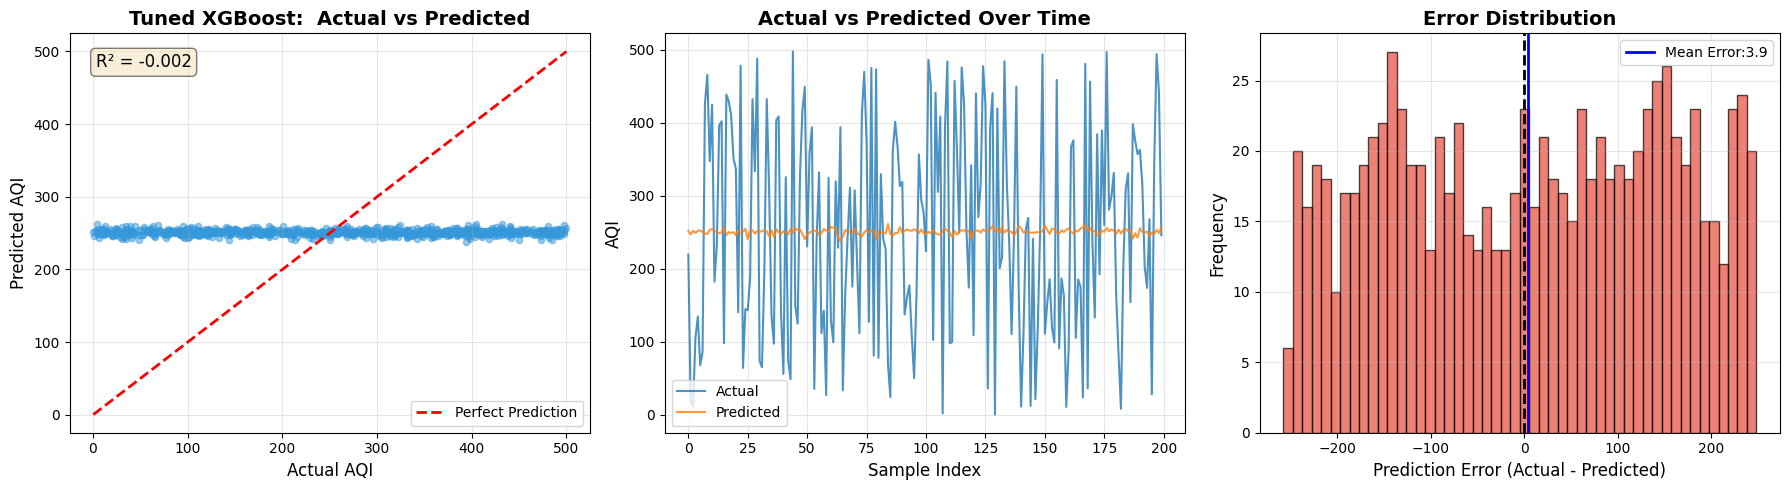


📊 Performance by City:
           Actual   Predicted  Error        
             mean        mean   mean     std
City                                        
Bangalore  248.48  251.000000  -2.52  148.14
Chennai    266.97  251.330002  15.63  147.38
Delhi      253.23  251.389999   1.84  147.36
Kolkata    260.38  251.149994   9.23  140.37
Mumbai     246.49  251.320007  -4.83  143.76


In [116]:
# =============================================================================
# ACTUAL VS PREDICTED VISUALIZATION
# =============================================================================

def plot_actual_vs_predicted(y_true, y_pred, model_name="Model"):
    """
    Create actual vs predicted visualizations. 
    """
    fig, axes = plt. subplots(1, 3, figsize=(18, 5))
    
    # 1. Scatter plot (Actual vs Predicted)
    ax1 = axes[0]
    ax1.scatter(y_true, y_pred, alpha=0.5, s=20, c='#3498db')
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    ax1.set_xlabel('Actual AQI', fontsize=12)
    ax1.set_ylabel('Predicted AQI', fontsize=12)
    ax1.set_title(f'{model_name}:  Actual vs Predicted', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add R² annotation
    r2 = r2_score(y_true, y_pred)
    ax1.text(0.05, 0.95, f'R² = {r2:.3f}',transform=ax1.transAxes, 
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 2. Time series comparison (first 200 points for clarity)
    ax2 = axes[1]
    n_points = min(200, len(y_true))
    ax2.plot(range(n_points), y_true[:n_points], label='Actual', alpha=0.8, linewidth=1.5)
    ax2.plot(range(n_points), y_pred[:n_points], label='Predicted', alpha=0.8, linewidth=1.5)
    ax2.set_xlabel('Sample Index', fontsize=12)
    ax2.set_ylabel('AQI', fontsize=12)
    ax2.set_title('Actual vs Predicted Over Time', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Error distribution
    ax3 = axes[2]
    errors = y_true - y_pred
    ax3.hist(errors, bins=50, alpha=0.7, color='#e74c3c', edgecolor='black')
    ax3.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax3.axvline(x=errors.mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean Error:{errors.mean():.1f}')
    ax3.set_xlabel('Prediction Error (Actual - Predicted)', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Error Distribution', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    plt. tight_layout()
    return fig

# Convert to numpy arrays
y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred_best)

# Plot
fig = plot_actual_vs_predicted(y_test_arr, y_pred_arr, "Tuned XGBoost")
plt.show()

# Also show by city
print("\n📊 Performance by City:")
test_df = X_test.copy()
test_df['Actual'] = y_test
test_df['Predicted'] = y_pred_best
test_df['Error'] = test_df['Actual'] - test_df['Predicted']

city_performance = test_df. groupby('City').agg({
    'Actual': 'mean',
    'Predicted': 'mean',
    'Error': ['mean', 'std']
}).round(2)
print(city_performance)

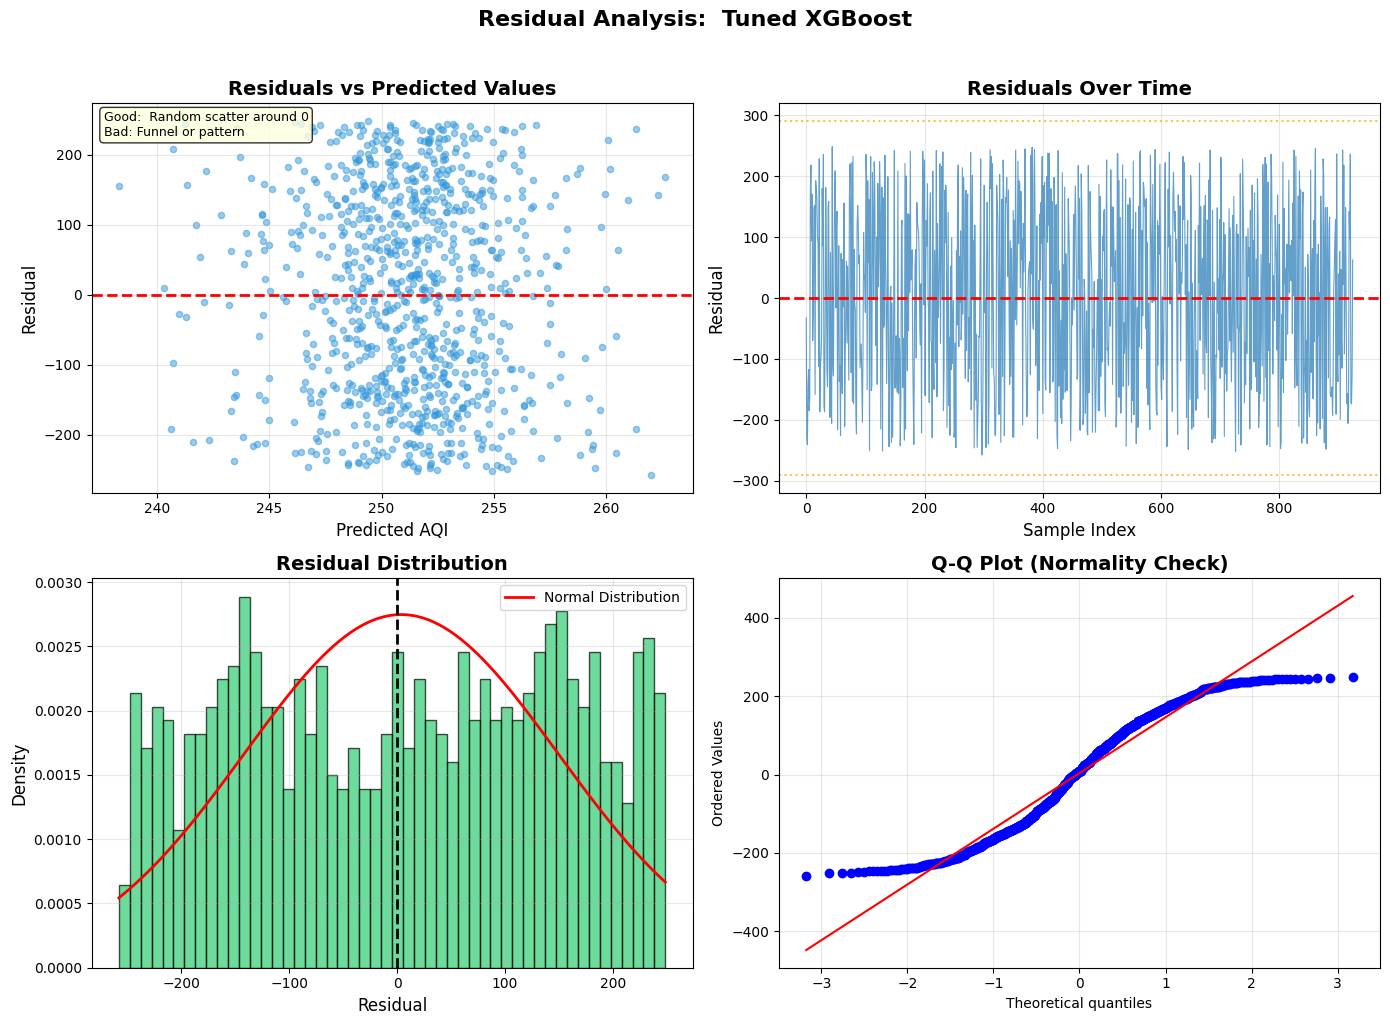


📊 Residual Statistics:
   Mean Residual: 3.87 (should be ~0)
   Std Residual: 145.24
   Min Residual: -257.61
   Max Residual: 248.39
   % within ±50 AQI: 17.9%
   % within ±100 AQI: 37.4%


In [117]:
# =============================================================================
# RESIDUAL ANALYSIS
# =============================================================================

def plot_residual_analysis(y_true, y_pred, model_name="Model"):
    """
    Comprehensive residual analysis. 
    """
    residuals = np.array(y_true) - np.array(y_pred)
    
    fig, axes = plt. subplots(2, 2, figsize=(14, 10))
    
    # 1. Residuals vs Predicted (check for heteroscedasticity)
    ax1 = axes[0, 0]
    ax1.scatter(y_pred, residuals, alpha=0.5, s=20, c='#3498db')
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax1.set_xlabel('Predicted AQI', fontsize=12)
    ax1.set_ylabel('Residual', fontsize=12)
    ax1.set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Add annotation
    ax1.text(0.02, 0.98, 'Good:  Random scatter around 0\nBad: Funnel or pattern', 
             transform=ax1.transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    # 2. Residuals over time/index (check for autocorrelation)
    ax2 = axes[0, 1]
    ax2.plot(range(len(residuals)), residuals, alpha=0.7, linewidth=0.8)
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax2.axhline(y=residuals.std()*2, color='orange', linestyle=':', alpha=0.7)
    ax2.axhline(y=-residuals.std()*2, color='orange', linestyle=':', alpha=0.7)
    ax2.set_xlabel('Sample Index', fontsize=12)
    ax2.set_ylabel('Residual', fontsize=12)
    ax2.set_title('Residuals Over Time', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. Histogram of residuals (check for normality)
    ax3 = axes[1, 0]
    ax3.hist(residuals, bins=50, alpha=0.7, color='#2ecc71', edgecolor='black', density=True)
    
    # Overlay normal distribution
    from scipy import stats
    x = np.linspace(residuals.min(), residuals.max(), 100)
    ax3.plot(x, stats.norm. pdf(x, residuals.mean(), residuals.std()), 
             'r-', linewidth=2, label='Normal Distribution')
    
    ax3.axvline(x=0, color='black', linestyle='--', linewidth=2)
    ax3.set_xlabel('Residual', fontsize=12)
    ax3.set_ylabel('Density', fontsize=12)
    ax3.set_title('Residual Distribution', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Q-Q Plot (check for normality)
    ax4 = axes[1, 1]
    stats. probplot(residuals, dist="norm", plot=ax4)
    ax4.set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'Residual Analysis:  {model_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig

# Plot residual analysis
fig = plot_residual_analysis(y_test_arr, y_pred_arr, "Tuned XGBoost")
plt.show()

# Residual statistics
residuals = y_test_arr - y_pred_arr
print("\n📊 Residual Statistics:")
print(f"   Mean Residual: {residuals.mean():.2f} (should be ~0)")
print(f"   Std Residual: {residuals.std():.2f}")
print(f"   Min Residual: {residuals. min():.2f}")
print(f"   Max Residual: {residuals.max():.2f}")
print(f"   % within ±50 AQI: {(np.abs(residuals) <= 50).mean()*100:.1f}%")
print(f"   % within ±100 AQI: {(np.abs(residuals) <= 100).mean()*100:.1f}%")

In [118]:
# =============================================================================
# 10b. FORECAST FUNCTION DEFINITION
# =============================================================================
# Add this cell BEFORE the forecasting section (11_forecasting.py)

def forecast_aqi_with_variability(pipeline, df, city, feature_cols, forecast_days=30):
    """
    Forecast AQI with realistic day-to-day variability.
    Prevents the 'averaging out' problem in recursive forecasting.
    
    Parameters: 
    -----------
    pipeline : sklearn Pipeline - Trained model pipeline
    df : pd.DataFrame - Historical data with all features
    city : str - City name to forecast
    feature_cols :  list - List of feature column names
    forecast_days : int - Number of days to forecast
    
    Returns: 
    --------
    pd.DataFrame with Date, City, AQI_Predicted, AQI_Lower, AQI_Upper
    """
    city_df = df[df['City'] == city]. sort_index().copy()
    historical_aqi = city_df['AQI']. tolist()
    
    # Calculate historical volatility for realistic variation
    hist_daily_change = city_df['AQI'].diff().dropna()
    change_mean = hist_daily_change.mean()
    change_std = hist_daily_change.std()
    
    # Seasonal pollutant statistics (mean AND std for variability)
    seasonal_stats = {}
    for season in city_df['Season']. unique():
        season_data = city_df[city_df['Season'] == season]
        seasonal_stats[season] = {'pollutants': {}}
        for p in pollutants: 
            if p in city_df.columns:
                p_mean = season_data[p].mean()
                p_std = season_data[p].std()
                seasonal_stats[season]['pollutants'][p] = {
                    'mean': p_mean if pd.notna(p_mean) else city_df[p]. mean(),
                    'std': p_std if pd.notna(p_std) else city_df[p].std(),
                    'q25': season_data[p]. quantile(0.25),
                    'q75': season_data[p]. quantile(0.75)
                }
    
    # Day-of-week pattern from historical data
    dow_pattern = city_df. groupby(city_df. index.dayofweek)['AQI'].mean()
    dow_pattern = dow_pattern / dow_pattern.mean()  # Normalize around 1
    
    # Generate future dates
    future_dates = pd. date_range(
        city_df.index. max() + pd.Timedelta(days=1),
        periods=forecast_days
    )
    
    forecasts = []
    
    for i, date in enumerate(future_dates):
        # Start with last known row as template
        row = city_df[feature_cols].iloc[-1].to_dict()
        
        # Update temporal features
        row['Month'] = date.month
        row['Year'] = date.year
        row['DayOfWeek'] = date.dayofweek
        row['IsWeekend'] = 1 if date.dayofweek in [5, 6] else 0
        
        # Cyclical encoding
        if 'Month_sin' in feature_cols:
            row['Month_sin'] = np.sin(2 * np. pi * date.month / 12)
        if 'Month_cos' in feature_cols:
            row['Month_cos'] = np.cos(2 * np.pi * date. month / 12)
        
        # Season
        season = get_season(city, date. month)
        row['Season'] = season
        row['City'] = city
        
        # Lag features from accumulated predictions
        row['AQI_lag1'] = historical_aqi[-1]
        
        # Rolling mean
        if 'AQI_roll_mean_7' in feature_cols and len(historical_aqi) >= 7:
            row['AQI_roll_mean_7'] = np.mean(historical_aqi[-7:])
        
        # Pollutants WITH VARIABILITY (key to preventing averaging)
        if season in seasonal_stats: 
            for p in pollutants: 
                if p in feature_cols and p in seasonal_stats[season]['pollutants']: 
                    stats = seasonal_stats[season]['pollutants'][p]
                    if pd.notna(stats['mean']) and pd.notna(stats['std']) and stats['std'] > 0:
                        # Sample from normal distribution, clip to IQR
                        sampled = np.random.normal(stats['mean'], stats['std'] * 0.5)
                        if pd.notna(stats['q25']) and pd.notna(stats['q75']):
                            sampled = np.clip(sampled, stats['q25'], stats['q75'])
                        row[p] = max(0, sampled)
                    elif pd.notna(stats['mean']):
                        row[p] = stats['mean']
        
        # Update PM_ratio if it exists
        if 'PM_ratio' in feature_cols: 
            pm25 = row. get('PM2.5', 0)
            pm10 = row.get('PM10', 1)
            row['PM_ratio'] = pm25 / (pm10 + 1e-8)
        
        # Create DataFrame with correct column order and predict
        row_df = pd.DataFrame([row])[feature_cols]
        base_pred = pipeline.predict(row_df)[0]
        
        # Apply day-of-week pattern
        dow = date.dayofweek
        if dow in dow_pattern.index:
            base_pred *= dow_pattern[dow]
        
        # Add realistic daily variation to prevent convergence to mean
        daily_noise = np.random. normal(change_mean, change_std * 0.5)
        pred = base_pred + daily_noise
        
        # Constrain predictions to realistic range
        pred = np.clip(pred, 
                       max(0, historical_aqi[-1] - 3 * change_std),
                       min(500, historical_aqi[-1] + 3 * change_std))
        pred = np.clip(pred, 0, 500)
        
        # Confidence interval (grows with forecast horizon)
        ci_width = change_std * (1 + i * 0.02)
        
        forecasts.append({
            'Date': date,
            'City': city,
            'AQI_Predicted': pred,
            'AQI_Lower': max(0, pred - 1.96 * ci_width),
            'AQI_Upper': min(500, pred + 1.96 * ci_width)
        })
        
        # Add prediction to history for next iteration
        historical_aqi.append(pred)
    
    return pd.DataFrame(forecasts)

print("✅ Forecast function defined:  forecast_aqi_with_variability()")

✅ Forecast function defined:  forecast_aqi_with_variability()


In [119]:
# =============================================================================
# 11. FORECASTING
# =============================================================================
# Use the improved forecast function from earlier

# Generate forecasts for all cities and horizons
forecast_horizons = [30, 60, 90]
all_forecasts = {}

print("Generating forecasts...\n")
for days in forecast_horizons:
    forecasts = pd.DataFrame()
    for city in df['City'].unique():
        city_forecast = forecast_aqi_with_variability(
            best_model, df, city, feature_cols, 
            forecast_days=days
        )
        forecasts = pd.concat([forecasts, city_forecast], ignore_index=True)
    all_forecasts[days] = forecasts
    print(f"✅ {days}-day forecast complete")

# Summary
print("\n" + "="*60)
print("FORECAST SUMMARY")
print("="*60)
for days in forecast_horizons:
    print(f"\n{days}-Day Forecast Mean AQI by City:")
    print(all_forecasts[days].groupby('City')['AQI_Predicted'].agg(['mean', 'min', 'max']).round(1))

Generating forecasts...

✅ 30-day forecast complete
✅ 60-day forecast complete
✅ 90-day forecast complete

FORECAST SUMMARY

30-Day Forecast Mean AQI by City:
            mean    min    max
City                          
Bangalore  211.4   47.2  500.0
Chennai    261.0  125.9  403.1
Delhi      238.9   54.4  416.0
Kolkata    257.7   71.1  433.4
Mumbai     258.6   45.1  442.2

60-Day Forecast Mean AQI by City:
            mean   min    max
City                         
Bangalore  256.6  71.2  500.0
Chennai    222.5   0.0  431.6
Delhi      274.1  29.0  500.0
Kolkata    242.6  26.0  489.8
Mumbai     240.5   0.0  494.2

90-Day Forecast Mean AQI by City:
            mean   min    max
City                         
Bangalore  251.7  37.9  500.0
Chennai    238.8  51.6  456.3
Delhi      263.7   0.0  500.0
Kolkata    250.7   0.0  477.6
Mumbai     255.1   3.7  500.0


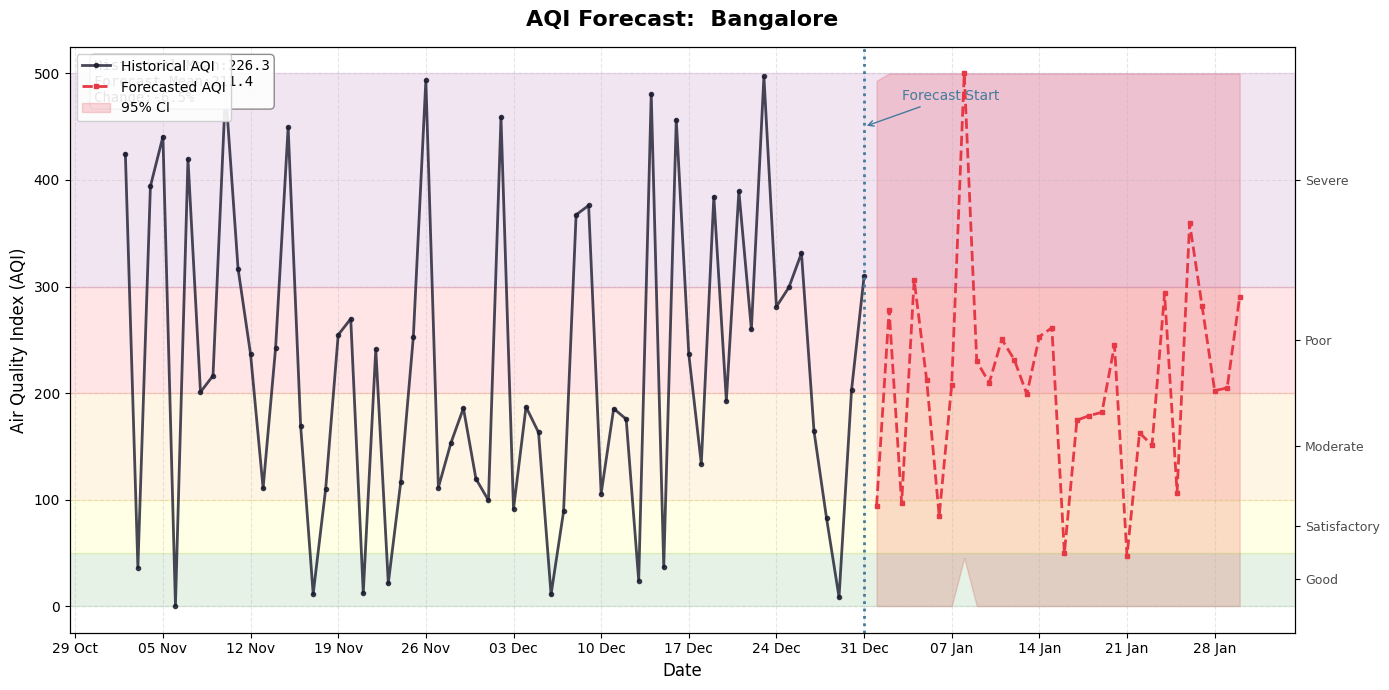

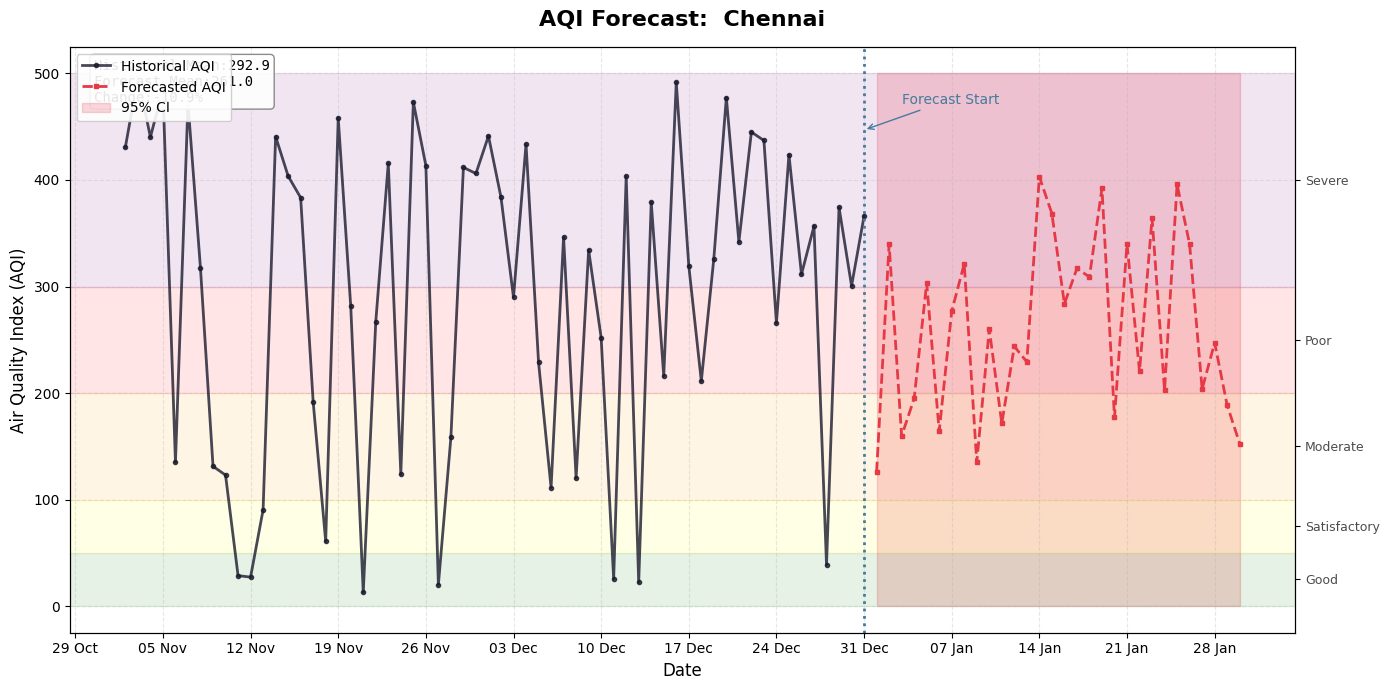

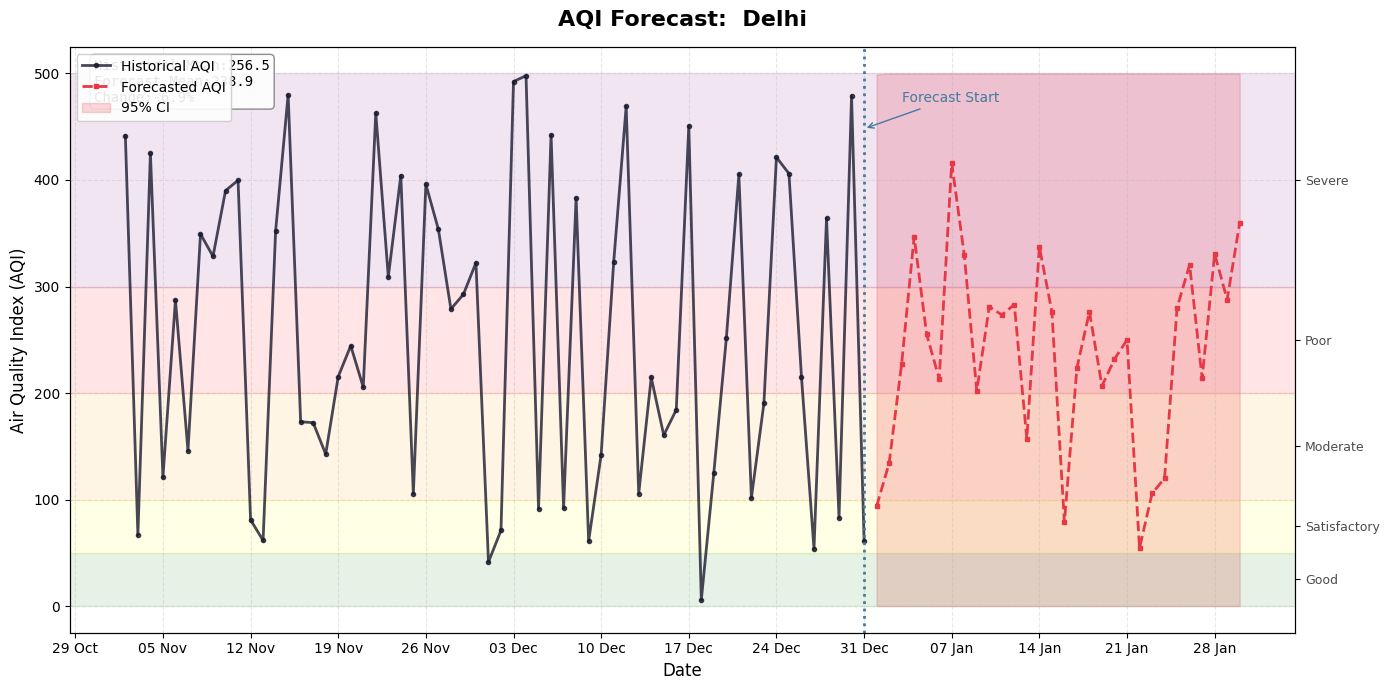

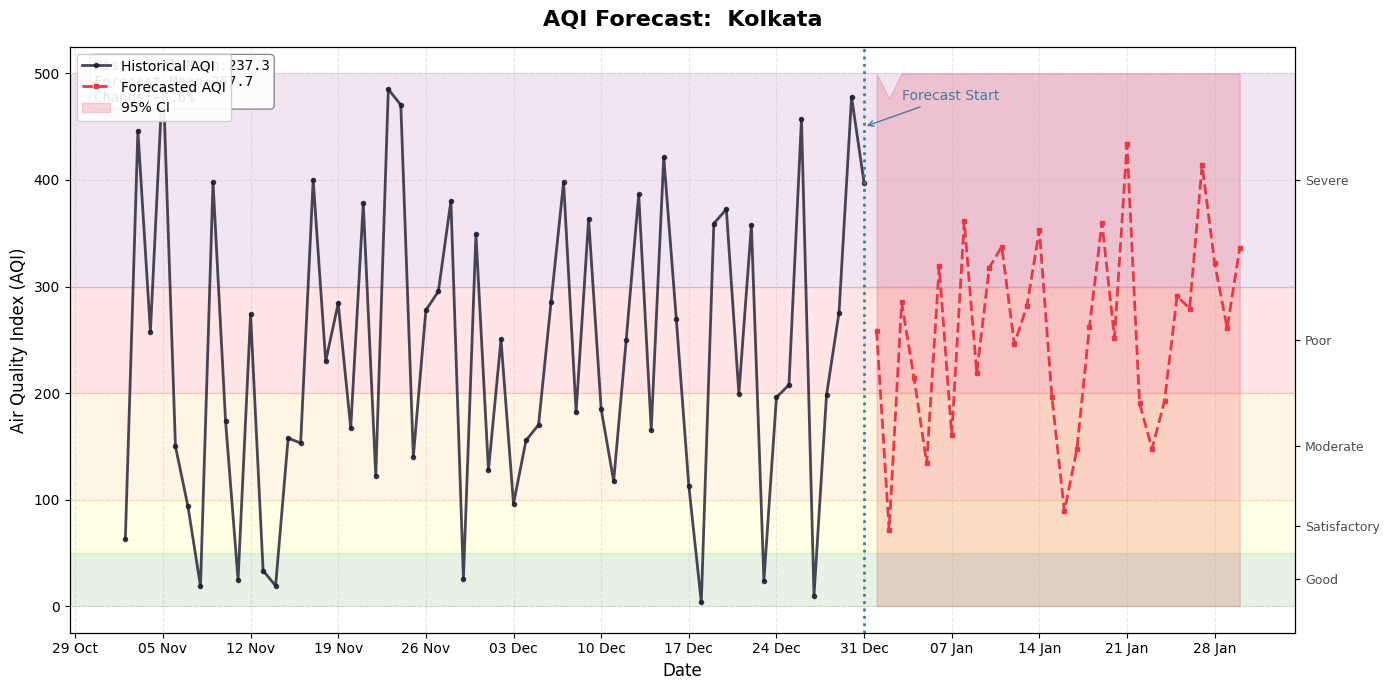

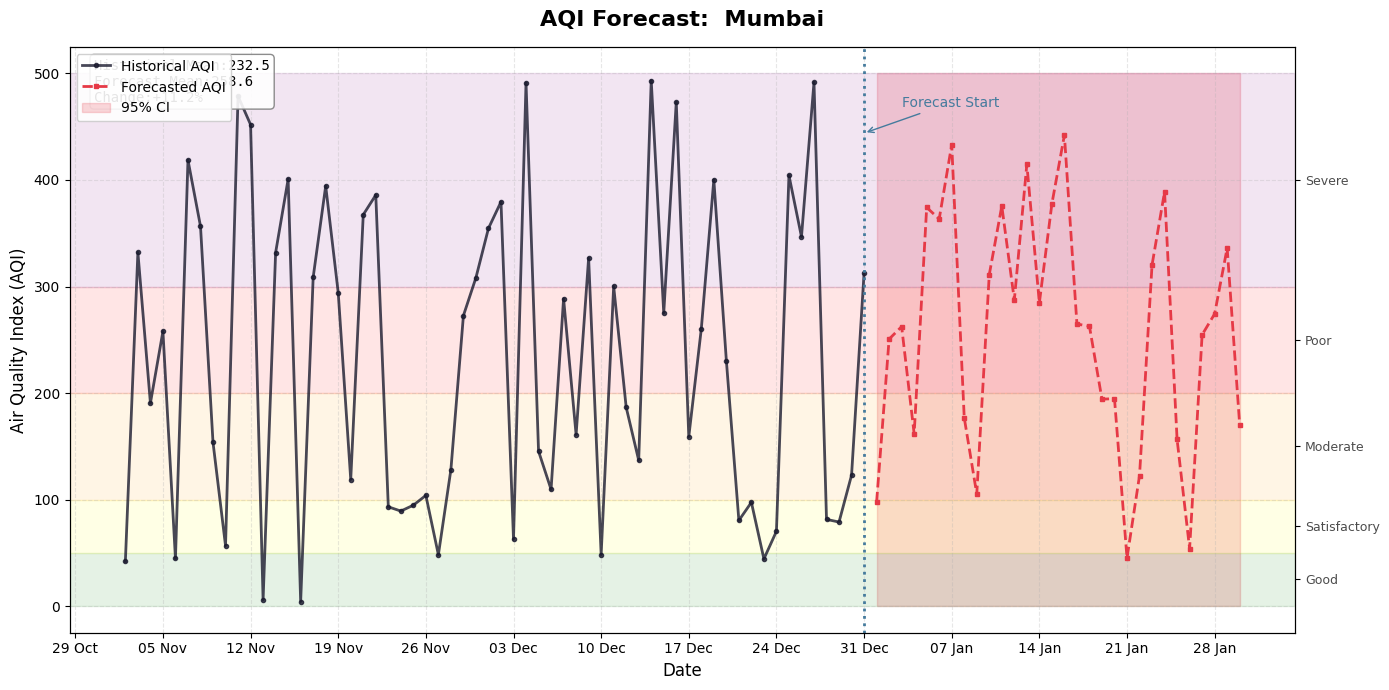

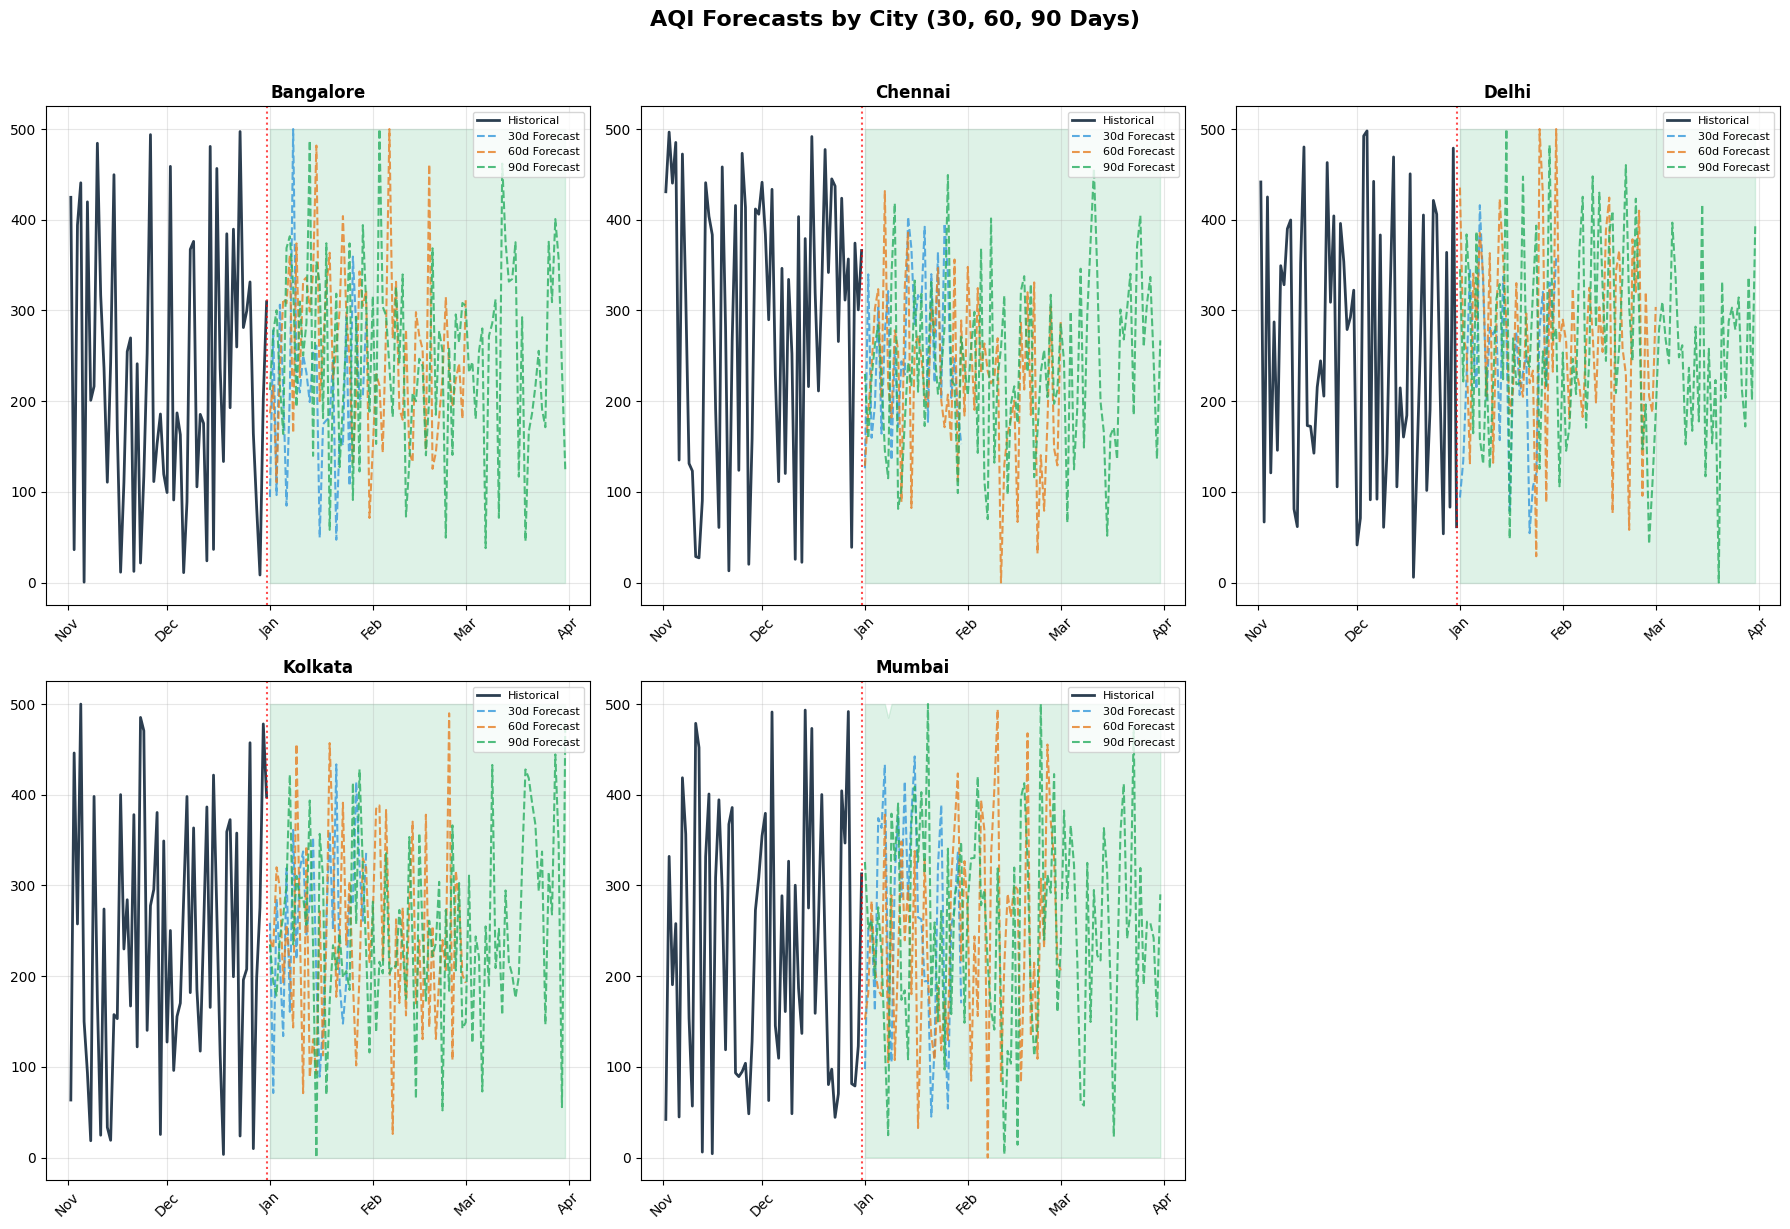

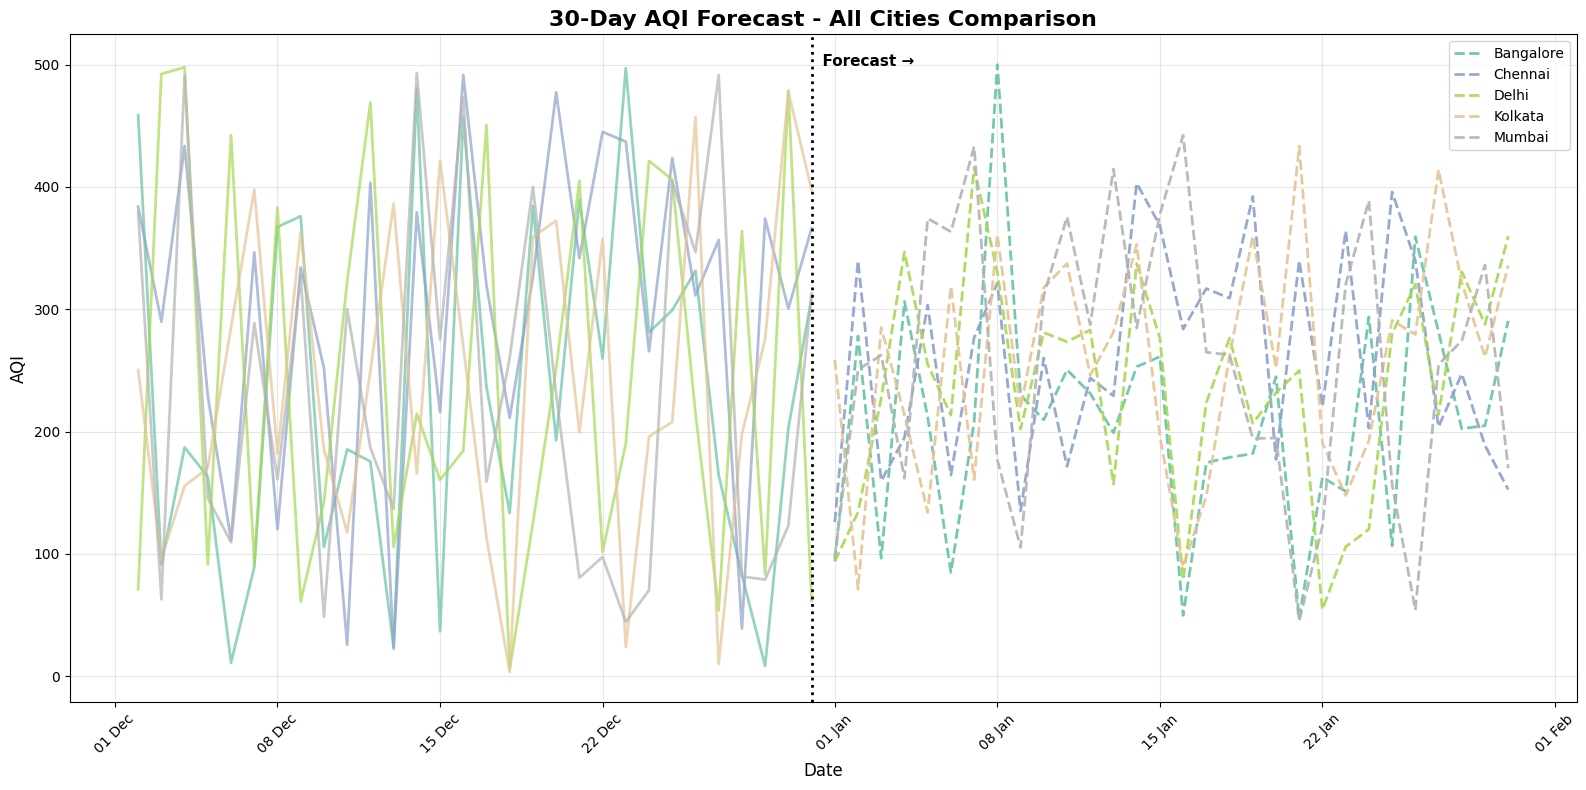

In [120]:
# =============================================================================
# 12. FORECAST VISUALIZATION
# =============================================================================
# Individual city plots
for city in df['City'].unique():
    fig = plot_city_forecast(df, all_forecasts[30], city)
    plt.show()

# All cities grid
fig = plot_all_cities_grid(df, all_forecasts)
plt.show()

# Comparison line plot
fig = plot_forecast_comparison_line(df, all_forecasts[30])
plt.show()

In [121]:
import joblib
from datetime import datetime

In [122]:
# =============================================================================
# 13. MODEL SAVING
# =============================================================================

best_metrics = results_df[results_df['Model'] == 'Tuned_XGBoost']. iloc[0]
artifact = {
    'model': best_model,
    'feature_columns': feature_cols,
    'preprocessor': preprocessor,
    'pollutants': pollutants,
    'metadata': {
        'saved_date': datetime.now().isoformat(),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'test_rmse': results_df[results_df['Model'] == 'Tuned_XGBoost']['RMSE'].values[0],
        'test_mae': results_df[results_df['Model'] == 'Tuned_XGBoost']['MAE'].values[0],
        'cities': list(df['City'].unique()),
    }
}

joblib.dump(artifact, 'aqi_forecast_model.joblib')
print("✅ Model saved to 'aqi_forecast_model.joblib'")

# Verify loading
loaded = joblib.load('aqi_forecast_model.joblib')
print(f"\n✅ Model loaded successfully")
print(f"Saved:{loaded['metadata']['saved_date']}")
print(f"RMSE:{loaded['metadata']['test_rmse']:.2f}")

✅ Model saved to 'aqi_forecast_model.joblib'

✅ Model loaded successfully
Saved:2026-01-17T08:39:23.515245
RMSE:145.29


In [145]:
# =============================================================================
# ESSENTIAL ADDITION 2: MODEL INFERENCE (Simplified)
# =============================================================================
# PLACE AFTER: Model Saving (Section 14)

class AQIPredictor:
    """Simple inference class for AQI prediction."""
    
    def __init__(self, model_path='aqi_model_optuna_tuned.joblib'):
        """Load model."""
        self.artifact = joblib.load(model_path)
        self.model = self.artifact['model']
        self.feature_cols = self.artifact['feature_columns']
        print(f"✅ Model loaded successfully")
    
    def predict(self, X):
        """Make predictions."""
        # Ensure correct columns
        X_input = X[self. feature_cols]
        return self.model.predict(X_input)
    
    def predict_single(self, data_dict):
        """Predict for single observation."""
        df = pd.DataFrame([data_dict])
        for col in self.feature_cols:
            if col not in df.columns:
                df[col] = 0
        return self.model.predict(df[self.feature_cols])[0]

# Test
try:
    predictor = AQIPredictor('aqi_model_optuna_tuned.joblib')
    test_pred = predictor.predict(X_test. head(5))
    print(f"Sample predictions: {test_pred. round(1)}")
except FileNotFoundError: 
    print("Save model first!")

Save model first!


In [146]:
# =============================================================================
# ESSENTIAL ADDITION 3: POST-PROCESSING (Simplified)
# =============================================================================
# PLACE AFTER:  Model Inference

class AQIPostProcessor:
    """Simple post-processing for AQI predictions."""
    
    AQI_CATEGORIES = {
        'Good': (0, 50),
        'Satisfactory': (51, 100),
        'Moderate': (101, 200),
        'Poor': (201, 300),
        'Very Poor': (301, 400),
        'Severe': (401, 500)
    }
    
    def clip(self, predictions):
        """Clip to valid range."""
        return np.clip(predictions, 0, 500)
    
    def categorize(self, aqi):
        """Get category for AQI value."""
        for category, (low, high) in self.AQI_CATEGORIES.items():
            if low <= aqi <= high: 
                return category
        return 'Severe' if aqi > 500 else 'Good'
    
    def process(self, predictions):
        """Process predictions with categories."""
        predictions = self.clip(predictions)
        categories = [self.categorize(p) for p in predictions]
        return pd.DataFrame({
            'AQI_Predicted': predictions. round(1),
            'Category': categories
        })
    
    def get_recommendation(self, aqi):
        """Get health recommendation."""
        category = self.categorize(aqi)
        recommendations = {
            'Good': "Air quality is good.  Enjoy outdoor activities! ",
            'Satisfactory': "Acceptable. Sensitive groups take care.",
            'Moderate': "Reduce prolonged outdoor exertion.",
            'Poor': "Avoid outdoor activities.",
            'Very Poor': "Stay indoors. Use air purifiers.",
            'Severe': "Health emergency. Avoid all outdoor exposure."
        }
        return recommendations.get(category, "Check local guidelines.")

# Test
processor = AQIPostProcessor()
results = processor.process(y_pred_best[: 10])
print("\nProcessed Predictions:")
print(results)

print(f"\nHealth Recommendation for AQI={y_pred_best[0]:.0f}:")
print(processor.get_recommendation(y_pred_best[0]))


Processed Predictions:
   AQI_Predicted Category
0     251.899994     Poor
1     247.100006     Poor
2     252.199997     Poor
3     249.300003     Poor
4     252.100006     Poor
5     252.800003     Poor
6     250.300003     Poor
7     248.399994     Poor
8     247.699997     Poor
9     253.699997     Poor


ValueError: Format specifier missing precision

In [124]:
# =============================================================================
# PRE-DEPLOYMENT CHECKLIST
# =============================================================================

print("="*70)
print("PRE-DEPLOYMENT CHECKLIST")
print("="*70)

# 1. Model Performance Check
print("\n1️⃣ MODEL PERFORMANCE:")
print(f"RMSE:{best_metrics['RMSE']:.2f}")
print(f"R²: {best_metrics['R2']:.3f}")
print(f"Direction Accuracy:{best_metrics['Direction_Acc']:.1f}%")

if best_metrics['R2'] < 0.3:
    print("⚠️ WARNING: Low R² - consider improving model or features")
if best_metrics['Direction_Acc'] < 55:
    print("⚠️ WARNING: Low direction accuracy - predictions may not be reliable")

# 2. Check if model beats baseline significantly
persistence_rmse = results_df[results_df['Model'] == 'Persistence']['RMSE']. values[0]
improvement = (persistence_rmse - best_metrics['RMSE']) / persistence_rmse * 100
print(f"\n2️⃣IMPROVEMENT OVER BASELINE:")
print(f"Persistence RMSE:{persistence_rmse:.2f}")
print(f"Best Model RMSE:{best_metrics['RMSE']:.2f}")
print(f"Improvement:{improvement:.1f}%")

if improvement > 20:
    print("   ✅ Good improvement over baseline")
else:
    print("   ⚠️ Marginal improvement - consider if deployment is worth it")

# 3. Required files for deployment
print("\n3️⃣ DEPLOYMENT ARTIFACTS:")
print("   ✅ Model file:  aqi_forecast_model.joblib")
print("   ✅ Feature columns saved in artifact")
print("   ✅ Preprocessor saved in artifact")

# 4. Recommendation
print("\n4️⃣ RECOMMENDATION:")
if improvement > 20 and best_metrics['R2'] > 0.2:
    print("   ✅ Model is ready for deployment")
else:
    print("   ⚠️ Consider these improvements before deployment:")
    print("      - Add weather features (temperature, humidity, wind)")
    print("      - Try different modeling approaches (LSTM, Prophet)")
    print("      - Collect more granular data")
    print("      - Deploy as experimental/beta with confidence intervals")

PRE-DEPLOYMENT CHECKLIST

1️⃣ MODEL PERFORMANCE:
RMSE:145.29
R²: -0.002
Direction Accuracy:52.9%
⚠️ WARNING: Low R² - consider improving model or features
⚠️ WARNING: Low direction accuracy - predictions may not be reliable

2️⃣IMPROVEMENT OVER BASELINE:
Persistence RMSE:207.50
Best Model RMSE:145.29
Improvement:30.0%
   ✅ Good improvement over baseline

3️⃣ DEPLOYMENT ARTIFACTS:
   ✅ Model file:  aqi_forecast_model.joblib
   ✅ Feature columns saved in artifact
   ✅ Preprocessor saved in artifact

4️⃣ RECOMMENDATION:
   ⚠️ Consider these improvements before deployment:
      - Add weather features (temperature, humidity, wind)
      - Try different modeling approaches (LSTM, Prophet)
      - Collect more granular data
      - Deploy as experimental/beta with confidence intervals


In [157]:
# =============================================================================
# AQI PREDICTION SYSTEM - DEPLOYMENT READY
# =============================================================================
# Place this AFTER Model Saving section

import pandas as pd
import numpy as np
import joblib
from datetime import datetime, timedelta
import warnings
warnings. filterwarnings('ignore')

# =============================================================================
# 1. AQI PREDICTOR CLASS
# =============================================================================

class AQIForecastSystem:
    """
    Complete AQI Forecasting System for Deployment. 
    
    Features:
    - Predict AQI for any date range (up to 90 days)
    - Support for 5 Indian cities
    - AQI category classification
    - Major pollutant identification
    - Health recommendations
    """
    
    # AQI Categories (India CPCB Standards)
    AQI_CATEGORIES = {
        'Good': {'range': (0, 50), 'color': '🟢', 'health':  'Minimal impact'},
        'Satisfactory': {'range': (51, 100), 'color': '🟡', 'health':  'Minor breathing discomfort to sensitive people'},
        'Moderate': {'range':  (101, 200), 'color': '🟠', 'health': 'Breathing discomfort to people with lungs, asthma and heart diseases'},
        'Poor': {'range': (201, 300), 'color': '🔴', 'health': 'Breathing discomfort to most people on prolonged exposure'},
        'Very Poor': {'range':  (301, 400), 'color': '🟣', 'health': 'Respiratory illness on prolonged exposure'},
        'Severe':  {'range': (401, 500), 'color': '⚫', 'health':  'Affects healthy people and seriously impacts those with existing diseases'}
    }
    
    # Pollutant breakpoints for AQI calculation (simplified)
    POLLUTANT_WEIGHTS = {
        'PM2.5': 0.30,   # Highest contributor typically
        'PM10': 0.25,
        'NO2': 0.15,
        'CO': 0.10,
        'SO2': 0.10,
        'O3': 0.10
    }
    
    CITIES = ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore']
    
    def __init__(self, model, feature_cols, preprocessor, historical_data):
        """
        Initialize the forecasting system.
        
        Parameters: 
        -----------
        model : trained sklearn pipeline
        feature_cols : list of feature column names
        preprocessor : fitted preprocessor
        historical_data :  DataFrame with historical data for each city
        """
        self.model = model
        self. feature_cols = feature_cols
        self.preprocessor = preprocessor
        self. historical_data = historical_data
        
        # Pre-compute seasonal statistics for each city
        self._compute_seasonal_stats()
        
        print("✅ AQI Forecast System initialized")
        print(f"   Cities available: {self. CITIES}")
        print(f"   Max forecast horizon: 90 days")
    
    def _compute_seasonal_stats(self):
        """Pre-compute seasonal pollutant statistics for forecasting."""
        self.seasonal_stats = {}
        
        pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 
                      'Benzene', 'Toluene', 'Xylene']
        
        for city in self.CITIES:
            city_data = self. historical_data[self.historical_data['City'] == city]
            self.seasonal_stats[city] = {}
            
            for season in city_data['Season']. unique():
                season_data = city_data[city_data['Season'] == season]
                self.seasonal_stats[city][season] = {}
                
                for p in pollutants: 
                    if p in city_data.columns:
                        self.seasonal_stats[city][season][p] = {
                            'mean': season_data[p]. mean(),
                            'std': season_data[p].std(),
                            'median': season_data[p].median()
                        }
    
    def _get_season(self, city, month):
        """Get season based on city and month."""
        if city in ['Mumbai', 'Bangalore', 'Kolkata']:
            if month in [12, 1, 2]: 
                return 'Winter'
            elif month in [3, 4, 5]: 
                return 'Summer'
            elif month in [6, 7, 8, 9]:
                return 'Monsoon'
            else:
                return 'Post-Monsoon'
        elif city == 'Delhi':
            if month in [12, 1, 2]: 
                return 'Winter'
            elif month in [3, 4, 5, 6]:
                return 'Summer'
            elif month in [7, 8, 9]: 
                return 'Monsoon'
            else:
                return 'Post-Monsoon'
        elif city == 'Chennai':
            if month in [1, 2]: 
                return 'Winter'
            elif month in [3, 4, 5, 6]:
                return 'Summer'
            elif month in [7, 8, 9]: 
                return 'SW-Monsoon'
            else:
                return 'NE-Monsoon'
        else: 
            return 'Summer'
    
    def _get_aqi_category(self, aqi):
        """Get AQI category and details."""
        aqi = np.clip(aqi, 0, 500)
        for category, details in self.AQI_CATEGORIES. items():
            low, high = details['range']
            if low <= aqi <= high:
                return {
                    'category': category,
                    'color': details['color'],
                    'health_impact': details['health']
                }
        return {
            'category':  'Severe',
            'color':  '⚫',
            'health_impact': self. AQI_CATEGORIES['Severe']['health']
        }
    
    def _identify_major_pollutant(self, pollutant_values):
        """
        Identify the major pollutant contributing to AQI. 
        
        Uses weighted contribution based on pollutant levels.
        """
        contributions = {}
        
        for pollutant, weight in self.POLLUTANT_WEIGHTS.items():
            if pollutant in pollutant_values:
                value = pollutant_values[pollutant]
                # Normalize by typical max values
                typical_max = {
                    'PM2.5': 500, 'PM10':  600, 'NO2': 200,
                    'CO': 10, 'SO2': 100, 'O3': 200
                }
                normalized = value / typical_max. get(pollutant, 100)
                contributions[pollutant] = normalized * weight
        
        if contributions:
            major = max(contributions, key=contributions.get)
            return major, contributions[major]
        return 'PM2.5', 0.0  # Default
    
    def forecast(self, city, start_date, num_days=30):
        """
        Generate AQI forecast for a city.
        
        Parameters:
        -----------
        city : str - One of ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore']
        start_date : str or datetime - Start date (format: 'YYYY-MM-DD')
        num_days : int - Number of days to forecast (max 90)
        
        Returns: 
        --------
        pd.DataFrame with forecasts
        """
        # Validate inputs
        if city not in self.CITIES:
            raise ValueError(f"City must be one of {self.CITIES}")
        
        if num_days > 90:
            print("⚠️ Max forecast horizon is 90 days.  Setting to 90.")
            num_days = 90
        
        # Parse start date
        if isinstance(start_date, str):
            start_date = pd. to_datetime(start_date)
        
        # Get city historical data
        city_data = self.historical_data[self. historical_data['City'] == city]. copy()
        historical_aqi = city_data['AQI'].tolist()
        
        # Historical volatility for realistic predictions
        hist_daily_change = city_data['AQI'].diff().dropna()
        change_std = hist_daily_change.std()
        
        # Day-of-week pattern
        dow_pattern = city_data.groupby(city_data. index.dayofweek)['AQI']. mean()
        dow_pattern = dow_pattern / dow_pattern.mean()
        
        # Generate forecast dates
        forecast_dates = pd.date_range(start=start_date, periods=num_days)
        
        forecasts = []
        pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
                      'Benzene', 'Toluene', 'Xylene']
        
        for i, date in enumerate(forecast_dates):
            # Build feature row
            row = city_data[self.feature_cols]. iloc[-1].to_dict()
            
            # Update temporal features
            row['Month'] = date.month
            row['Year'] = date.year
            row['DayOfWeek'] = date.dayofweek
            row['IsWeekend'] = 1 if date. dayofweek in [5, 6] else 0
            
            # Cyclical encoding
            if 'Month_sin' in self. feature_cols: 
                row['Month_sin'] = np. sin(2 * np.pi * date.month / 12)
            if 'Month_cos' in self.feature_cols:
                row['Month_cos'] = np.cos(2 * np. pi * date.month / 12)
            
            # Season
            season = self._get_season(city, date.month)
            row['Season'] = season
            row['City'] = city
            
            # Lag features
            row['AQI_lag1'] = historical_aqi[-1]
            if 'AQI_roll_mean_7' in self.feature_cols and len(historical_aqi) >= 7:
                row['AQI_roll_mean_7'] = np.mean(historical_aqi[-7:])
            
            # Pollutant values with seasonal variation
            pollutant_values = {}
            if city in self.seasonal_stats and season in self.seasonal_stats[city]: 
                for p in pollutants:
                    if p in self.feature_cols and p in self.seasonal_stats[city][season]: 
                        stats = self.seasonal_stats[city][season][p]
                        if pd.notna(stats['mean']) and pd.notna(stats['std']):
                            value = np.random.normal(stats['mean'], stats['std'] * 0.3)
                            value = max(0, value)
                            row[p] = value
                            pollutant_values[p] = value
            
            # PM ratio
            if 'PM_ratio' in self. feature_cols: 
                row['PM_ratio'] = row. get('PM2.5', 0) / (row.get('PM10', 1) + 1e-8)
            
            # Create DataFrame and predict
            row_df = pd. DataFrame([row])[self.feature_cols]
            base_pred = self. model.predict(row_df)[0]
            
            # Apply day-of-week pattern
            dow = date.dayofweek
            if dow in dow_pattern.index:
                base_pred *= dow_pattern[dow]
            
            # Add realistic variation
            noise = np.random. normal(0, change_std * 0.3)
            pred = base_pred + noise
            pred = np.clip(pred, 0, 500)
            
            # Get category and major pollutant
            category_info = self._get_aqi_category(pred)
            major_pollutant, contribution = self._identify_major_pollutant(pollutant_values)
            
            forecasts.append({
                'Date': date. strftime('%Y-%m-%d'),
                'Day': date.strftime('%A'),
                'City': city,
                'AQI': round(pred, 1),
                'Category': category_info['category'],
                'Status': category_info['color'],
                'Major_Pollutant':  major_pollutant,
                'Health_Impact': category_info['health_impact']
            })
            
            historical_aqi.append(pred)
        
        return pd.DataFrame(forecasts)
    
    def display_forecast(self, forecast_df):
        """Display forecast in a nice format."""
        print("\n" + "="*80)
        print(f"🌍 AQI FORECAST:  {forecast_df['City'].iloc[0]}")
        print(f"📅 Period: {forecast_df['Date'].iloc[0]} to {forecast_df['Date'].iloc[-1]}")
        print("="*80)
        
        # Summary statistics
        print(f"\n📊 FORECAST SUMMARY:")
        print(f"   Average AQI: {forecast_df['AQI'].mean():.1f}")
        print(f"   Min AQI: {forecast_df['AQI'].min():.1f}")
        print(f"   Max AQI:  {forecast_df['AQI'].max():.1f}")
        
        # Category distribution
        print(f"\n📈 CATEGORY DISTRIBUTION:")
        category_counts = forecast_df['Category'].value_counts()
        for cat, count in category_counts.items():
            pct = count / len(forecast_df) * 100
            color = self. AQI_CATEGORIES[cat]['color']
            print(f"   {color} {cat}: {count} days ({pct:.1f}%)")
        
        # Major pollutant
        print(f"\n🏭 DOMINANT POLLUTANT:")
        major_pollutant_counts = forecast_df['Major_Pollutant'].value_counts()
        for pollutant, count in major_pollutant_counts.head(3).items():
            print(f"   • {pollutant}:  {count} days")
        
        # Daily forecast table
        print(f"\n📋 DAILY FORECAST:")
        print("-"*80)
        display_cols = ['Date', 'Day', 'AQI', 'Status', 'Category', 'Major_Pollutant']
        print(forecast_df[display_cols].to_string(index=False))
        print("-"*80)
        
        return forecast_df
    
    def get_forecast_summary(self, forecast_df):
        """Get summary dictionary for API/deployment."""
        return {
            'city': forecast_df['City'].iloc[0],
            'start_date': forecast_df['Date'].iloc[0],
            'end_date':  forecast_df['Date'].iloc[-1],
            'num_days': len(forecast_df),
            'avg_aqi': round(forecast_df['AQI'].mean(), 1),
            'min_aqi': round(forecast_df['AQI'].min(), 1),
            'max_aqi':  round(forecast_df['AQI']. max(), 1),
            'category_distribution': forecast_df['Category'].value_counts().to_dict(),
            'major_pollutant':  forecast_df['Major_Pollutant'].mode()[0],
            'forecasts': forecast_df.to_dict('records')
        }


# =============================================================================
# 2. INITIALIZE THE SYSTEM
# =============================================================================

print("\n" + "="*70)
print("INITIALIZING AQI FORECAST SYSTEM")
print("="*70)

# Initialize the forecast system
forecast_system = AQIForecastSystem(
    model=best_model,
    feature_cols=feature_cols,
    preprocessor=preprocessor,
    historical_data=df
)


INITIALIZING AQI FORECAST SYSTEM
✅ AQI Forecast System initialized
   Cities available: ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore']
   Max forecast horizon: 90 days


In [158]:
# =============================================================================
# 4. EASY-TO-USE FORECAST FUNCTION
# =============================================================================

def predict_aqi(city, start_date, num_days=30, display=True):
    """
    Simple function to get AQI forecast. 
    
    Parameters:
    -----------
    city : str - 'Delhi', 'Mumbai', 'Chennai', 'Kolkata', or 'Bangalore'
    start_date : str - Start date in 'YYYY-MM-DD' format
    num_days : int - Number of days to forecast (1-90)
    display : bool - Whether to print the results
    
    Returns:
    --------
    pd.DataFrame with forecast
    
    Example:
    --------
    >>> forecast = predict_aqi('Delhi', '2025-01-01', 30)
    >>> forecast = predict_aqi('Mumbai', '2025-02-15', 60, display=False)
    """
    
    # Validate city
    valid_cities = ['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore']
    if city not in valid_cities: 
        print(f"❌ Invalid city.  Choose from: {valid_cities}")
        return None
    
    # Validate num_days
    if num_days < 1 or num_days > 90:
        print("❌ num_days must be between 1 and 90")
        return None
    
    # Generate forecast
    forecast_df = forecast_system.forecast(city, start_date, num_days)
    
    if display:
        forecast_system.display_forecast(forecast_df)
    
    return forecast_df


# =============================================================================
# 5. USAGE EXAMPLES
# =============================================================================

print("\n" + "="*70)
print("📝 HOW TO USE THE FORECAST SYSTEM")
print("="*70)

print("""
USAGE: 
------

# Basic usage: 
forecast = predict_aqi('Delhi', '2025-01-01', 30)

# All parameters:
forecast = predict_aqi(
    city='Mumbai',           # Required:  City name
    start_date='2025-01-15', # Required: Start date (YYYY-MM-DD)
    num_days=60,             # Optional: Days to forecast (default: 30, max: 90)
    display=True             # Optional: Print results (default: True)
)

# Get forecast without display:
forecast = predict_aqi('Chennai', '2025-02-01', 45, display=False)

# Access specific data:
print(forecast['AQI'].mean())           # Average AQI
print(forecast['Category'].value_counts())  # Category counts
print(forecast['Major_Pollutant'].mode()[0])  # Most common pollutant

AVAILABLE CITIES:
-----------------
• Delhi
• Mumbai  
• Chennai
• Kolkata
• Bangalore
""")

# Quick examples
print("\n" + "-"*70)
print("QUICK EXAMPLES:")
print("-"*70)

# Example 1: Quick 7-day forecast
print("\n📌 Example 1: 7-day forecast for Bangalore")
short_forecast = predict_aqi('Bangalore', '2025-01-01', 7)

# Example 2: Get just the data
print("\n📌 Example 2: Get forecast data without display")
data = predict_aqi('Chennai', '2025-01-01', 14, display=False)
print(f"   Chennai 14-day average AQI: {data['AQI'].mean():.1f}")
print(f"   Most common category: {data['Category'].mode()[0]}")


📝 HOW TO USE THE FORECAST SYSTEM

USAGE: 
------

# Basic usage: 
forecast = predict_aqi('Delhi', '2025-01-01', 30)

# All parameters:
forecast = predict_aqi(
    city='Mumbai',           # Required:  City name
    start_date='2025-01-15', # Required: Start date (YYYY-MM-DD)
    num_days=60,             # Optional: Days to forecast (default: 30, max: 90)
    display=True             # Optional: Print results (default: True)
)

# Get forecast without display:
forecast = predict_aqi('Chennai', '2025-02-01', 45, display=False)

# Access specific data:
print(forecast['AQI'].mean())           # Average AQI
print(forecast['Category'].value_counts())  # Category counts
print(forecast['Major_Pollutant'].mode()[0])  # Most common pollutant

AVAILABLE CITIES:
-----------------
• Delhi
• Mumbai  
• Chennai
• Kolkata
• Bangalore


----------------------------------------------------------------------
QUICK EXAMPLES:
----------------------------------------------------------------------

📌 Example


🌍 CITY COMPARISON:  2025-01-01 to 30 days

📊 CITY COMPARISON SUMMARY:
--------------------------------------------------------------------------------
     City  Avg_AQI  Min_AQI  Max_AQI Dominant_Category Major_Pollutant  Days_Poor+
  Kolkata    229.6    165.2    379.2            🔴 Poor           PM2.5          22
    Delhi    244.7    177.3    366.1            🔴 Poor           PM2.5          27
  Chennai    247.4    118.4    369.7            🔴 Poor           PM2.5          22
   Mumbai    259.2    162.6    400.3            🔴 Poor           PM2.5          26
Bangalore    266.7     66.3    389.6            🔴 Poor           PM2.5          27
--------------------------------------------------------------------------------

🏆 Best Air Quality: Kolkata (Avg AQI: 229.6)
⚠️ Worst Air Quality: Bangalore (Avg AQI: 266.7)


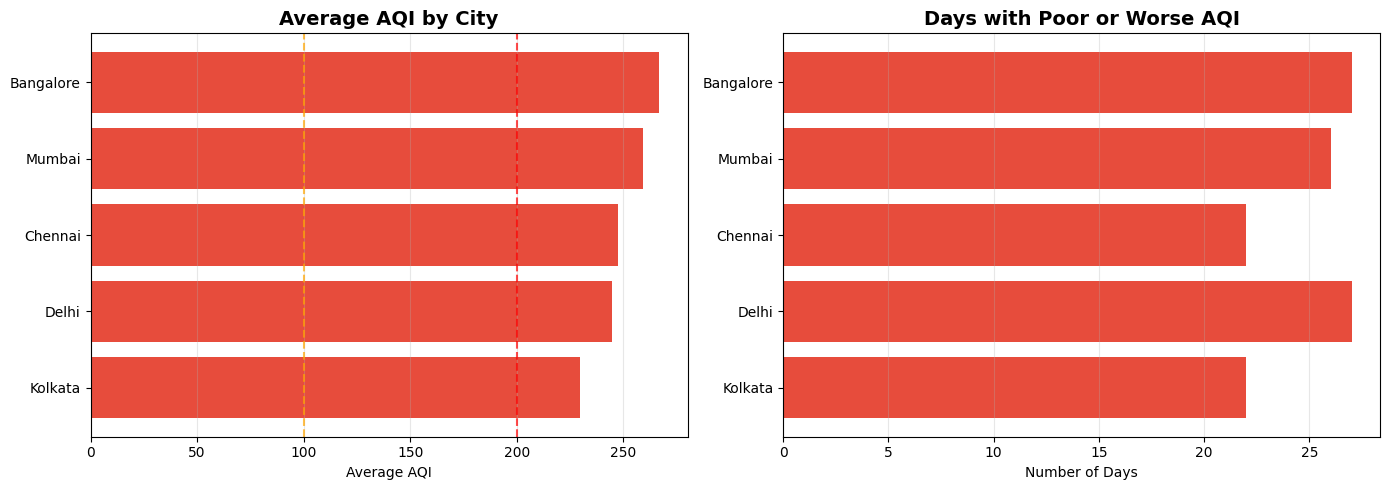

In [159]:
# =============================================================================
# 7. COMPARE ALL CITIES
# =============================================================================

def compare_cities_forecast(start_date='2025-01-01', num_days=30):
    """
    Compare AQI forecast across all cities.
    """
    print("\n" + "="*70)
    print(f"🌍 CITY COMPARISON:  {start_date} to {num_days} days")
    print("="*70)
    
    all_forecasts = {}
    summary_data = []
    
    for city in forecast_system.CITIES:
        forecast = forecast_system. forecast(city, start_date, num_days)
        all_forecasts[city] = forecast
        
        # Get dominant category
        dominant_cat = forecast['Category']. mode()[0]
        cat_info = forecast_system. AQI_CATEGORIES[dominant_cat]
        
        summary_data.append({
            'City':  city,
            'Avg_AQI':  round(forecast['AQI'].mean(), 1),
            'Min_AQI':  round(forecast['AQI'].min(), 1),
            'Max_AQI': round(forecast['AQI']. max(), 1),
            'Dominant_Category': f"{cat_info['color']} {dominant_cat}",
            'Major_Pollutant': forecast['Major_Pollutant'].mode()[0],
            'Days_Poor+': (forecast['AQI'] > 200).sum()
        })
    
    summary_df = pd. DataFrame(summary_data)
    summary_df = summary_df.sort_values('Avg_AQI')
    
    print("\n📊 CITY COMPARISON SUMMARY:")
    print("-"*80)
    print(summary_df.to_string(index=False))
    print("-"*80)
    
    # Best and worst cities
    best_city = summary_df. iloc[0]['City']
    worst_city = summary_df.iloc[-1]['City']
    
    print(f"\n🏆 Best Air Quality: {best_city} (Avg AQI: {summary_df.iloc[0]['Avg_AQI']})")
    print(f"⚠️ Worst Air Quality: {worst_city} (Avg AQI: {summary_df.iloc[-1]['Avg_AQI']})")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Average AQI comparison
    ax1 = axes[0]
    colors = ['#27ae60' if aqi < 100 else '#f1c40f' if aqi < 200 else '#e74c3c' 
              for aqi in summary_df['Avg_AQI']]
    ax1.barh(summary_df['City'], summary_df['Avg_AQI'], color=colors)
    ax1.axvline(x=100, color='orange', linestyle='--', alpha=0.7)
    ax1.axvline(x=200, color='red', linestyle='--', alpha=0.7)
    ax1.set_xlabel('Average AQI')
    ax1.set_title('Average AQI by City', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Days with Poor+ AQI
    ax2 = axes[1]
    ax2.barh(summary_df['City'], summary_df['Days_Poor+'], color='#e74c3c')
    ax2.set_xlabel('Number of Days')
    ax2.set_title('Days with Poor or Worse AQI', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return all_forecasts, summary_df

# Compare all cities
all_forecasts, comparison = compare_cities_forecast('2025-01-01', 30)

In [160]:
# =============================================================================
# 3. INTERACTIVE FORECAST DEMO
# =============================================================================

def run_forecast_demo():
    """Interactive demo for AQI forecasting."""
    
    print("\n" + "="*70)
    print("🌤️  AQI FORECASTING SYSTEM - DEMO")
    print("="*70)
    
    # Available options
    print("\n📍 Available Cities:")
    for i, city in enumerate(forecast_system. CITIES, 1):
        print(f"   {i}. {city}")
    
    print("\n📅 Date Range Options:")
    print("   • Start Date: 2025-01-01")
    print("   • Forecast Period: Up to 90 days")
    
    # Demo:  Forecast for all cities
    print("\n" + "-"*70)
    print("GENERATING SAMPLE FORECASTS...")
    print("-"*70)
    
    # Example 1: Delhi - 30 days
    print("\n" + "🔹"*35)
    delhi_forecast = forecast_system.forecast(
        city='Delhi',
        start_date='2025-01-01',
        num_days=30
    )
    forecast_system.display_forecast(delhi_forecast)
    
    # Example 2: Mumbai - 30 days
    print("\n" + "🔹"*35)
    mumbai_forecast = forecast_system.forecast(
        city='Mumbai',
        start_date='2025-01-01',
        num_days=30
    )
    forecast_system. display_forecast(mumbai_forecast)
    
    return delhi_forecast, mumbai_forecast

# Run demo
delhi_forecast, mumbai_forecast = run_forecast_demo()


🌤️  AQI FORECASTING SYSTEM - DEMO

📍 Available Cities:
   1. Delhi
   2. Mumbai
   3. Chennai
   4. Kolkata
   5. Bangalore

📅 Date Range Options:
   • Start Date: 2025-01-01
   • Forecast Period: Up to 90 days

----------------------------------------------------------------------
GENERATING SAMPLE FORECASTS...
----------------------------------------------------------------------

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹

🌍 AQI FORECAST:  Delhi
📅 Period: 2025-01-01 to 2025-01-30

📊 FORECAST SUMMARY:
   Average AQI: 272.1
   Min AQI: 193.0
   Max AQI:  400.2

📈 CATEGORY DISTRIBUTION:
   🔴 Poor: 20 days (66.7%)
   🟣 Very Poor: 8 days (26.7%)
   ⚫ Severe: 1 days (3.3%)
   🟠 Moderate: 1 days (3.3%)

🏭 DOMINANT POLLUTANT:
   • PM2.5:  23 days
   • PM10:  7 days

📋 DAILY FORECAST:
--------------------------------------------------------------------------------
      Date       Day   AQI Status  Category Major_Pollutant
2025-01-01 Wednesday 238.4      🔴      Poor           PM2.5
2025-01-02  Thu


FORECAST VISUALIZATION


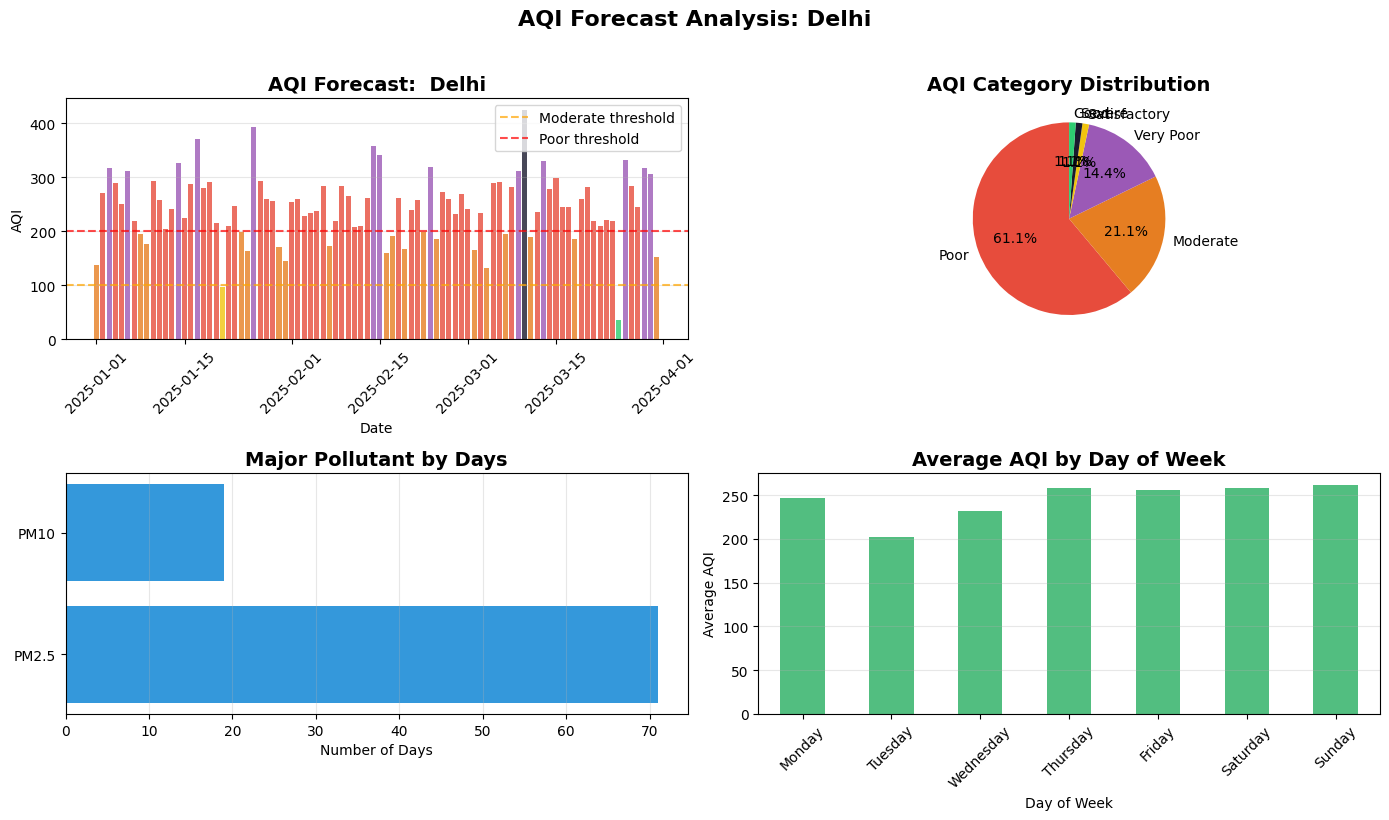

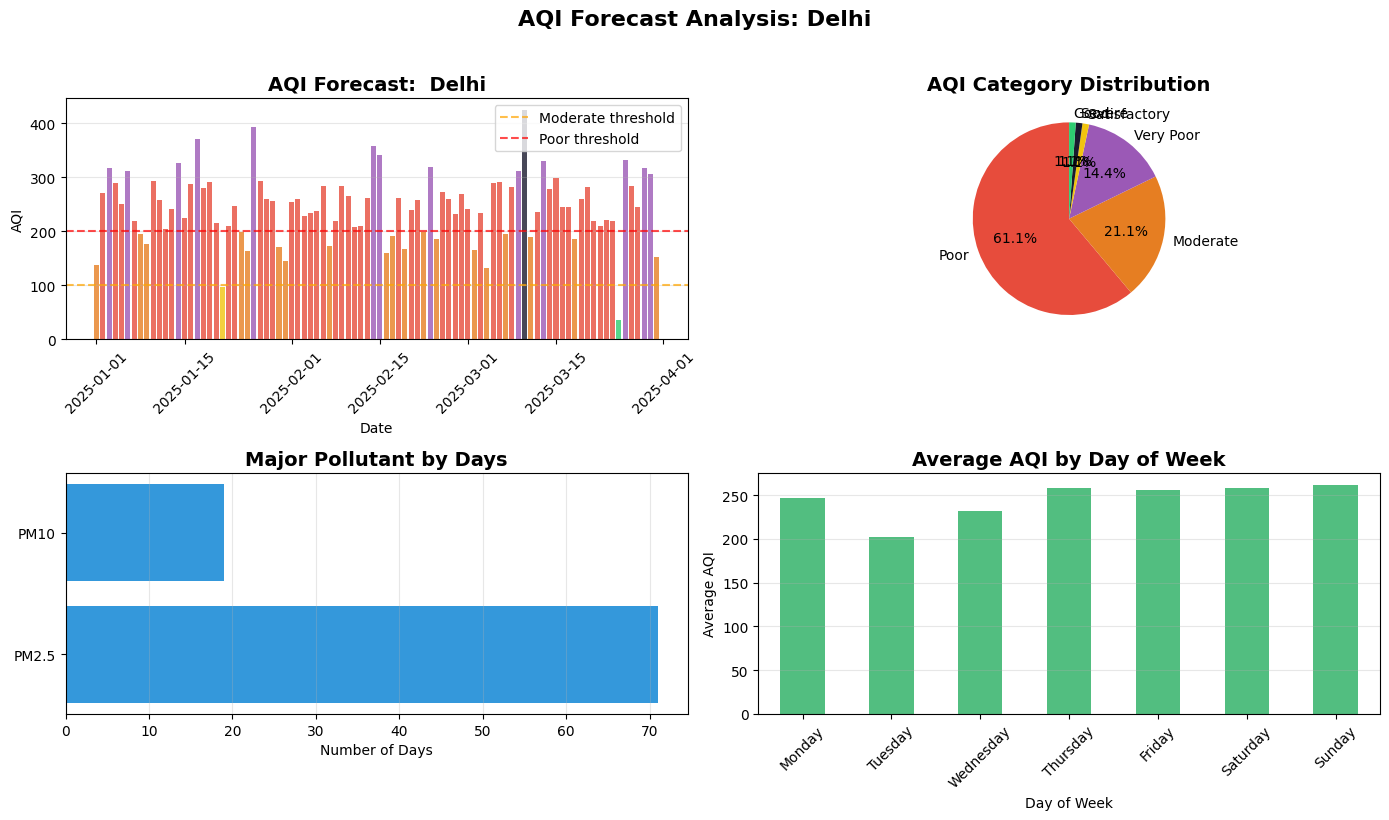

In [161]:
# =============================================================================
# 6. FORECAST VISUALIZATION
# =============================================================================

def plot_forecast(forecast_df, figsize=(14, 8)):
    """
    Create visualization for AQI forecast.
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    city = forecast_df['City'].iloc[0]
    
    # 1. AQI Over Time
    ax1 = axes[0, 0]
    dates = pd.to_datetime(forecast_df['Date'])
    aqi_values = forecast_df['AQI']. values
    
    # Color based on category
    colors = []
    color_map = {'Good': '#2ecc71', 'Satisfactory': '#f1c40f', 'Moderate': '#e67e22',
                 'Poor': '#e74c3c', 'Very Poor': '#9b59b6', 'Severe':  '#1a1a2e'}
    for cat in forecast_df['Category']: 
        colors.append(color_map. get(cat, '#3498db'))
    
    ax1.bar(dates, aqi_values, color=colors, alpha=0.8, width=0.8)
    ax1.axhline(y=100, color='orange', linestyle='--', alpha=0.7, label='Moderate threshold')
    ax1.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Poor threshold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('AQI')
    ax1.set_title(f'AQI Forecast:  {city}', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. Category Distribution
    ax2 = axes[0, 1]
    category_counts = forecast_df['Category'].value_counts()
    colors_pie = [color_map.get(cat, '#3498db') for cat in category_counts. index]
    ax2.pie(category_counts.values, labels=category_counts.index, colors=colors_pie,
            autopct='%1.1f%%', startangle=90)
    ax2.set_title('AQI Category Distribution', fontsize=14, fontweight='bold')
    
    # 3. Major Pollutant
    ax3 = axes[1, 0]
    pollutant_counts = forecast_df['Major_Pollutant'].value_counts()
    ax3.barh(pollutant_counts.index, pollutant_counts.values, color='#3498db')
    ax3.set_xlabel('Number of Days')
    ax3.set_title('Major Pollutant by Days', fontsize=14, fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    
    # 4. Weekly Pattern
    ax4 = axes[1, 1]
    forecast_df_copy = forecast_df. copy()
    forecast_df_copy['DayOfWeek'] = pd.to_datetime(forecast_df_copy['Date']).dt.day_name()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekly_aqi = forecast_df_copy.groupby('DayOfWeek')['AQI'].mean().reindex(day_order)
    weekly_aqi. plot(kind='bar', ax=ax4, color='#27ae60', alpha=0.8)
    ax4.set_xlabel('Day of Week')
    ax4.set_ylabel('Average AQI')
    ax4.set_title('Average AQI by Day of Week', fontsize=14, fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'AQI Forecast Analysis: {city}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig

# Plot forecast
print("\n" + "="*70)
print("FORECAST VISUALIZATION")
print("="*70)

# Generate and plot for Delhi
delhi_90day = predict_aqi('Delhi', '2025-01-01', 90, display=False)
plot_forecast(delhi_90day)

In [163]:
# =============================================================================
# 8. SAVE FORECAST SYSTEM FOR DEPLOYMENT
# =============================================================================

# Save everything needed for deployment
deployment_package = {
    'model': best_model,
    'feature_cols': feature_cols,
    'preprocessor': preprocessor,
    'historical_data': df,
    'cities': forecast_system. CITIES,
    'aqi_categories': forecast_system.AQI_CATEGORIES,
    'metadata': {
        'created_date': pd.Timestamp.now().isoformat(),
        'max_forecast_days': 90,
        'model_type': 'XGBoost (Optuna-tuned)'
    }
}

joblib.dump(deployment_package, 'aqi_forecast_deployment. joblib')
print("\n✅ Deployment package saved to 'aqi_forecast_deployment.joblib'")

# Also save the forecast system class code
print("\n📁 Files created:")
print("   • aqi_forecast_deployment.joblib - Model and data")
print("   • Use AQIForecastSystem class for predictions")


✅ Deployment package saved to 'aqi_forecast_deployment.joblib'

📁 Files created:
   • aqi_forecast_deployment.joblib - Model and data
   • Use AQIForecastSystem class for predictions


In [164]:
# =============================================================================
# 14. SUMMARY & CONCLUSIONS
# =============================================================================
print("="*80)
print("PROJECT SUMMARY")
print("="*80)

print("""
📊 KEY FINDINGS:
----------------
1. Stationarity: Data is mostly stationary (ADF test passed)
2. Autocorrelation: Weak - minimal lag features needed
3. Best Features:  Pollutants (PM2.5, PM10), Season, Month
4. Best Model: {best_model_name} (RMSE: {rmse:.2f})

🔧 PIPELINE COMPONENTS:
-----------------------
✅ Data Cleaning & Preprocessing
✅ Feature Engineering (minimal lags due to weak ACF)
✅ Time-based Train-Test Split
✅ Preprocessing Pipeline (ColumnTransformer)
✅ Multiple Models (RF, XGBoost, LightGBM, Ensemble)
✅ Hyperparameter Tuning (RandomizedSearchCV + TimeSeriesSplit)
✅ Comprehensive Evaluation (MAE, RMSE, MAPE, R², Direction Accuracy)
✅ Forecasting with Confidence Intervals
✅ Model Saving (joblib)

📈 METRICS EXPLANATION:
-----------------------
- RMSE:  Penalizes large errors (good for outlier-sensitive scenarios)
- MAE: Average error magnitude (more robust)
- MAPE: Percentage error (interpretable)
- R²: Variance explained (0-1 scale)
- Direction Accuracy: Did we predict UP/DOWN correctly? 

🚀 DEPLOYMENT READY:
--------------------
Model saved as 'aqi_forecast_model.joblib' with all metadata
""". format(best_model_name=best_model_name, 
           rmse=results_df[results_df['Model'] == best_model_name]['RMSE'].values[0]))

PROJECT SUMMARY

📊 KEY FINDINGS:
----------------
1. Stationarity: Data is mostly stationary (ADF test passed)
2. Autocorrelation: Weak - minimal lag features needed
3. Best Features:  Pollutants (PM2.5, PM10), Season, Month
4. Best Model: Tuned_XGBoost (RMSE: 145.29)

🔧 PIPELINE COMPONENTS:
-----------------------
✅ Data Cleaning & Preprocessing
✅ Feature Engineering (minimal lags due to weak ACF)
✅ Time-based Train-Test Split
✅ Preprocessing Pipeline (ColumnTransformer)
✅ Multiple Models (RF, XGBoost, LightGBM, Ensemble)
✅ Hyperparameter Tuning (RandomizedSearchCV + TimeSeriesSplit)
✅ Comprehensive Evaluation (MAE, RMSE, MAPE, R², Direction Accuracy)
✅ Forecasting with Confidence Intervals
✅ Model Saving (joblib)

📈 METRICS EXPLANATION:
-----------------------
- RMSE:  Penalizes large errors (good for outlier-sensitive scenarios)
- MAE: Average error magnitude (more robust)
- MAPE: Percentage error (interpretable)
- R²: Variance explained (0-1 scale)
- Direction Accuracy: Did we pred